<a href="https://colab.research.google.com/github/AditiNayak-S/NumericalTechniques-MAT1012-Report2/blob/main/NumericalTechniques_MAT1012_Report2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Numerical Methods & Computational Physics

Welcome to this computational laboratory notebook. The core objective of this coursework is to transition from abstract mathematical theory to practical, algorithmic execution.

In engineering and scientific computing, real-world problems often yield equations that are either mathematically impossible or highly inefficient to solve analytically by hand. Through the power of **Python**, we bridge this gap by implementing discrete numerical approximations.

### Core Pillars of the Lab:
1. **Error Management:** Finding the balance between discrete step sizes ($h$) and algorithmic accuracy.
2. **Computational Stability:** Respecting mathematical guardrails (like the CFL condition or convergence thresholds) to prevent numerical divergence.
3. **Data Visualization:** Mapping mathematical fields and trends dynamically using `matplotlib`.

## Laboratory Notebook Roadmap

Here is a summary of the advanced numerical implementations we will be exploring next in this notebook:

| Module Pillar | Core Focus | Methodologies Implemented |
| :--- | :--- | :--- |
| **1. Optimization & Roots** | Handling Multi-Root Convergence | Generalized Newton's Method |
| **2. Finite Differences** | Boundary Slope Approximations | Forward, Backward, and Central Difference Methods |
| **3. Interpolation** | Discrete to Continuous Modeling | Newton’s (Forward/Backward), Gauss (Forward/Backward), Stirling's, Lagrange's, and Divided Differences |
| **4. Statistical Fitting** | Regression Trend Mapping | Power Curve Fitting ($y=ax^b$) & Exponential Curve Fitting ($y=ae^{bx}$) |
| **5. Numerical Calculus** | Integration & Marching ODEs | Trapezoidal Rule, Simpson’s (1/3 & 3/8) Rules, Modified Euler’s, and 4th-Order Runge-Kutta (RK4) |
| **6. Field Simulations** | Partial Differential Equations (PDEs) | Explicit FTCS for Parabolic (Heat), CFL-constrained Hyperbolic (Wave), and Elliptic (Laplace) Stencils |

#Experiment 1: Roots of Equations

#1.1 Bisection Method
#Algorithm Logic

The Bisection Method works by repeatedly bisecting an interval $[a, b]$ where a root exists (indicated by $f(a) \cdot f(b) < 0$) and selecting the subinterval where the sign change occurs until the interval is sufficiently small.

Enter the function f(x): x**3 - x - 2
Enter lower bound (a): 5
Enter upper bound (b): -5
Enter error tolerance : 1e-5
Enter maximum iterations: 10

Iter a           b           c (Root)    f(c)        
-------------------------------------------------------
1    5.000000    -5.000000   0.000000    -2.000000   
2    5.000000    0.000000    2.500000    11.125000   
3    2.500000    0.000000    1.250000    -1.296875   
4    2.500000    1.250000    1.875000    2.716797    
5    1.875000    1.250000    1.562500    0.252197    
6    1.562500    1.250000    1.406250    -0.625336   
7    1.562500    1.406250    1.484375    -0.213749   
8    1.562500    1.484375    1.523438    0.012250    
9    1.523438    1.484375    1.503906    -0.102470   
10   1.523438    1.503906    1.513672    -0.045543   

Reached maximum iterations without achieving strict tolerance convergence.


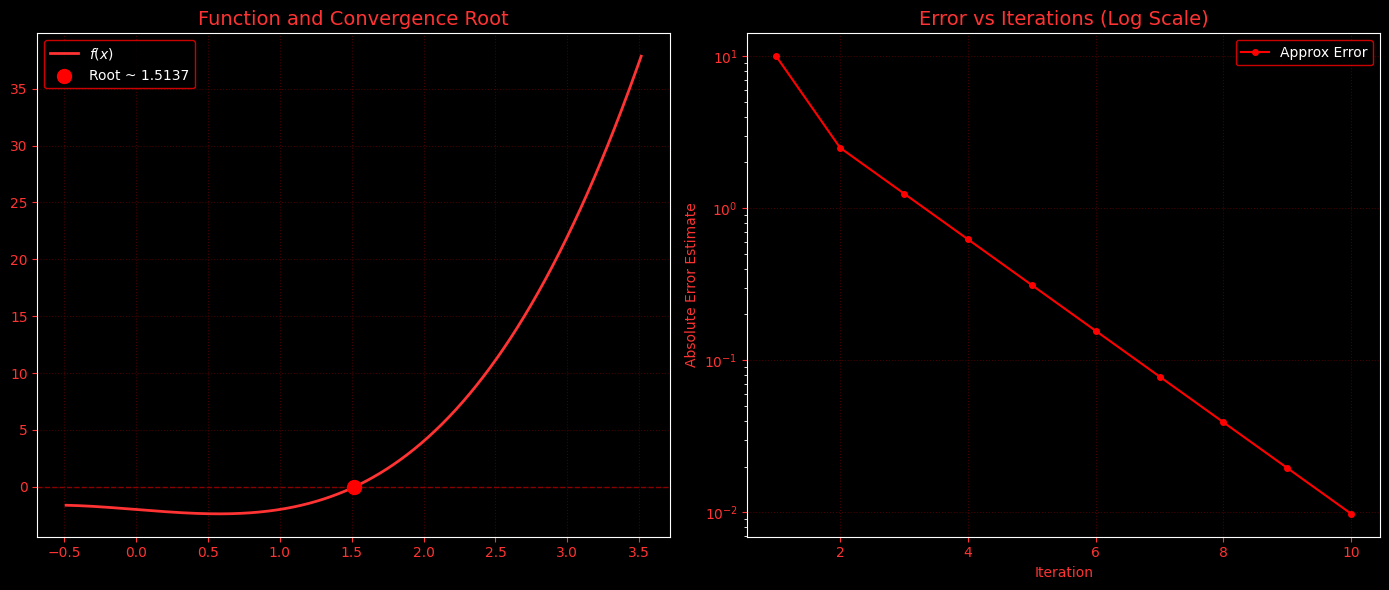

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set dark aesthetic globally
plt.style.use('dark_background')


# 1. User Inputs
func_str = input("Enter the function f(x): ")
f = lambda x: eval(func_str)

a = float(input("Enter lower bound (a): "))
b = float(input("Enter upper bound (b): "))
tol = float(input("Enter error tolerance : "))
max_iter = int(input("Enter maximum iterations: "))

# Checking validity of initial interval
if f(a) * f(b) >= 0:
    print("\n[Error]: f(a) and f(b) must have opposite signs. Bisection method cannot proceed.")
else:
    # 2. Bisection Core Logic
    iterations = []
    root_estimates = []
    errors = []

    print(f"\n{'Iter':<5}{'a':<12}{'b':<12}{'c (Root)':<12}{'f(c)':<12}")
    print("-" * 55)

    c_old = a
    for i in range(1, max_iter + 1):
        c = (a + b) / 2.0
        fc = f(c)

        iterations.append(i)
        root_estimates.append(c)

        # Calculate absolute approximate error after first iteration
        err = abs(c - c_old) if i > 1 else abs(b - a)
        errors.append(err)

        print(f"{i:<5}{a:<12.6f}{b:<12.6f}{c:<12.6f}{fc:<12.6f}")

        # Check termination criteria
        if abs(fc) < tol or err < tol:
            print(f"\nConvergence achieved at iteration {i}. Estimated Root: {c:.6f}")
            break

        # Decide the next subinterval
        if f(a) * fc < 0:
            b = c
        else:
            a = c
        c_old = c
    else:
        print("\nReached maximum iterations without achieving strict tolerance convergence.")

    # 3. Visualization Construction
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='#000000')

    # Left Plot: Function & Root Location
    ax1.set_facecolor('#000000')
    x_vals = np.linspace(root_estimates[-1] - 2, root_estimates[-1] + 2, 500)
    y_vals = f(x_vals)

    ax1.plot(x_vals, y_vals, color='#FF3333', linewidth=2, label='$f(x)$')
    ax1.axhline(0, color='#880000', linestyle='--', linewidth=1)
    ax1.scatter(root_estimates[-1], f(root_estimates[-1]), color='#FF0000', s=100, zorder=5, label=f'Root ~ {root_estimates[-1]:.4f}')

    ax1.set_title("Function and Convergence Root", color='#FF3333', fontsize=14)
    ax1.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax1.tick_params(colors='#FF3333')
    ax1.xaxis.label.set_color('#FF3333')
    ax1.yaxis.label.set_color('#FF3333')
    ax1.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

    # Right Plot: Error Trajectory over Iterations
    ax2.set_facecolor('#000000')
    ax2.plot(iterations, errors, color='#FF0000', marker='o', markersize=4, linestyle='-', linewidth=1.5, label='Approx Error')
    ax2.set_yscale('log')
    ax2.set_title("Error vs Iterations (Log Scale)", color='#FF3333', fontsize=14)
    ax2.set_xlabel("Iteration", color='#FF3333')
    ax2.set_ylabel("Absolute Error Estimate", color='#FF3333')
    ax2.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax2.tick_params(colors='#FF3333')
    ax2.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

    plt.tight_layout()
    plt.show()

### 1.2 Fixed-Point Iteration Method
### Algorithm Logic
The Fixed-Point Iteration Method transforms an equation $f(x) = 0$ into an algebraically equivalent form $x = g(x)$. Starting with an initial guess $x_0$, it runs the successive approximation chain $x_{n+1} = g(x_n)$.

Enter the converted function g(x) such that x = g(x) : (x + 2)**(1/3)
Enter initial guess (x0): 1.8
Enter error tolerance : 0.0001
Enter maximum iterations: 14

Iter x_n            g(x_n)         Absolute Error 
-------------------------------------------------------
1    1.800000       1.560491       0.239509       
2    1.560491       1.526992       0.033499       
3    1.526992       1.522187       0.004804       
4    1.522187       1.521496       0.000691       
5    1.521496       1.521396       0.000100       

Convergence achieved at iteration 5. Fixed Point Root: 1.521396


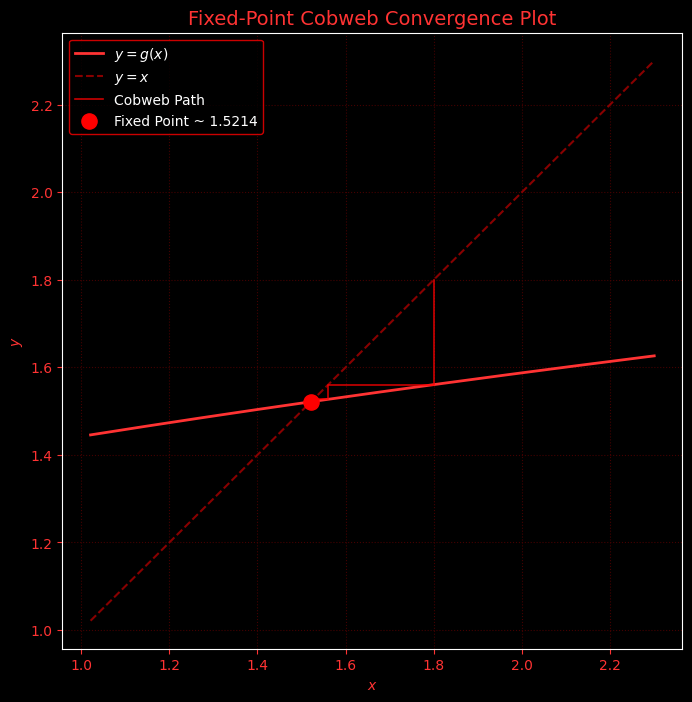

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')



# 1. User Inputs
g_str = input("Enter the converted function g(x) such that x = g(x) : ")
g = lambda x: eval(g_str)

x0 = float(input("Enter initial guess (x0): "))
tol = float(input("Enter error tolerance : "))
max_iter = int(input("Enter maximum iterations: "))

# 2. Fixed-Point Core Logic
history = [x0]
converged = False

print(f"\n{'Iter':<5}{'x_n':<15}{'g(x_n)':<15}{'Absolute Error':<15}")
print("-" * 55)

x_current = x0
for i in range(1, max_iter + 1):
    try:
        x_next = g(x_current)
    except Exception as e:
        print(f"\n[Error]: Functional evaluation failed due to math domain restrictions: {e}")
        break

    err = abs(x_next - x_current)
    print(f"{i:<5}{x_current:<15.6f}{x_next:<15.6f}{err:<15.6f}")

    history.append(x_next)

    if err < tol:
        print(f"\nConvergence achieved at iteration {i}. Fixed Point Root: {x_next:.6f}")
        converged = True
        break

    x_current = x_next

    # Simple divergence check guardrail
    if err > 1e10:
        print("\n[Warning]: Values are diverging rapidly. Terminating execution loop.")
        break
else:
    if not converged:
        print("\nReached maximum iterations without meeting strict tolerance limits.")

# 3. Cobweb Visualization Construction
if len(history) > 1:
    fig, ax = plt.subplots(figsize=(8, 8), facecolor='#000000')
    ax.set_facecolor('#000000')

    # Define plotting range based on history range
    xmin, xmax = min(history) - 0.5, max(history) + 0.5
    x_vals = np.linspace(xmin, xmax, 500)

    # Plot y = g(x) and identity y = x lines
    ax.plot(x_vals, g(x_vals), color='#FF3333', linewidth=2, label='$y = g(x)$')
    ax.plot(x_vals, x_vals, color='#880000', linestyle='--', linewidth=1.5, label='$y = x$')

    # Generate cobweb path vectors
    cobweb_x, cobweb_y = [], []
    for idx in range(len(history) - 1):
        # Vertical movement to curve g(x)
        cobweb_x.append(history[idx])
        cobweb_y.append(history[idx])

        # Horizontal movement to identity line
        cobweb_x.append(history[idx])
        cobweb_y.append(history[idx+1])

    ax.plot(cobweb_x, cobweb_y, color='#FF0000', linewidth=1.2, alpha=0.8, label='Cobweb Path')
    ax.scatter(history[-1], history[-1], color='#FF0000', s=120, zorder=6, label=f'Fixed Point ~ {history[-1]:.4f}')

    ax.set_title("Fixed-Point Cobweb Convergence Plot", color='#FF3333', fontsize=14)
    ax.set_xlabel("$x$", color='#FF3333')
    ax.set_ylabel("$y$", color='#FF3333')
    ax.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax.tick_params(colors='#FF3333')
    ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

    plt.show()

# Experiment 2: Roots of Equations

###2.1 Regula–Falsi (False Position) Method

# Algorithm Logic
The Regula–Falsi method finds roots by connecting points $(a, f(a))$ and $(b, f(b))$ with a straight line. The intersection of this line with the x-axis provides the root approximation $c$, calculated as:$$c = b - \frac{f(b) \cdot (b - a)}{f(b) - f(a)}$$

Enter the function f(x): x*3 - x - 2
Enter lower bound (a): -5
Enter upper bound (b): 7
Enter error tolerance: 1e-5
Enter maximum iterations: 21

Iter a           b           c (Root)    f(c)        
-------------------------------------------------------
1    -5.000000   7.000000    1.000000    0.000000    

Convergence achieved at iteration 1. Estimated Root: 1.000000


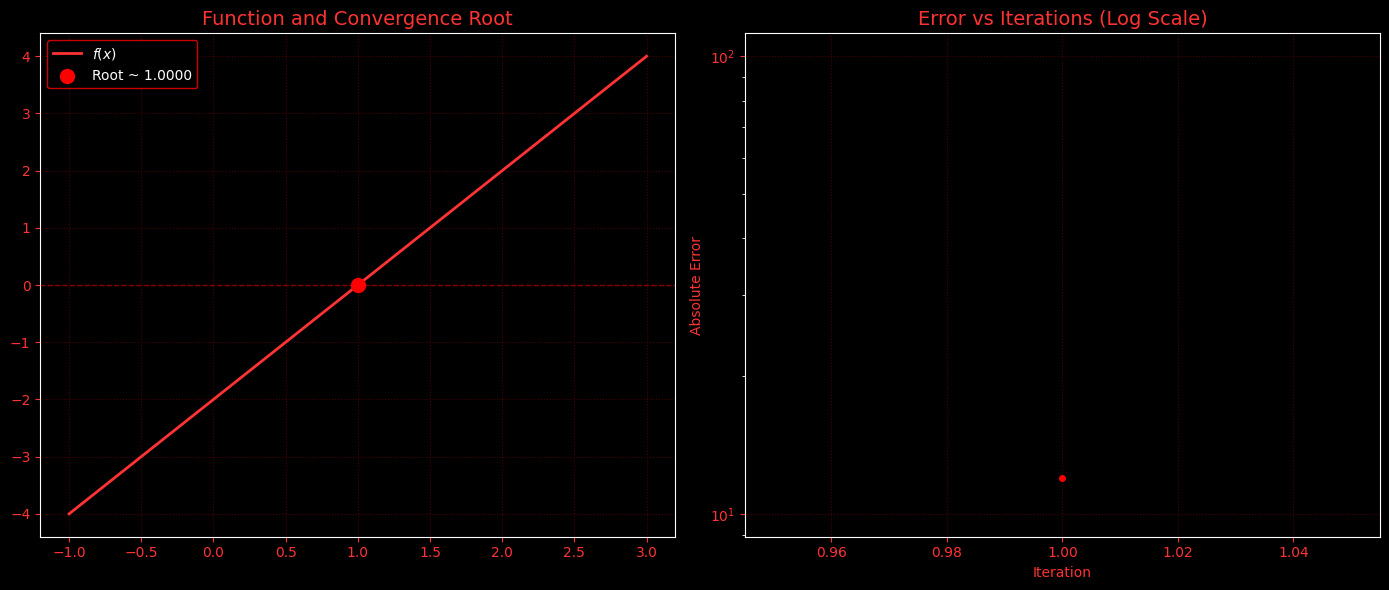

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x): ")
f = lambda x: eval(func_str)

a = float(input("Enter lower bound (a): "))
b = float(input("Enter upper bound (b): "))
tol = float(input("Enter error tolerance: "))
max_iter = int(input("Enter maximum iterations: "))

if f(a) * f(b) >= 0:
    print("\n[Error]: f(a) and f(b) must have opposite signs.")
else:
    iterations = []
    root_estimates = []
    errors = []

    print(f"\n{'Iter':<5}{'a':<12}{'b':<12}{'c (Root)':<12}{'f(c)':<12}")
    print("-" * 55)

    c_old = a
    for i in range(1, max_iter + 1):
        # Regula-Falsi interpolation formula
        c = b - (f(b) * (b - a)) / (f(b) - f(a))
        fc = f(c)

        iterations.append(i)
        root_estimates.append(c)

        err = abs(c - c_old) if i > 1 else abs(b - a)
        errors.append(err)

        print(f"{i:<5}{a:<12.6f}{b:<12.6f}{c:<12.6f}{fc:<12.6f}")

        if abs(fc) < tol or err < tol:
            print(f"\nConvergence achieved at iteration {i}. Estimated Root: {c:.6f}")
            break

        if f(a) * fc < 0:
            b = c
        else:
            a = c
        c_old = c
    else:
        print("\nReached maximum iterations without achieving convergence.")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='#000000')

    ax1.set_facecolor('#000000')
    x_vals = np.linspace(root_estimates[-1] - 2, root_estimates[-1] + 2, 500)
    ax1.plot(x_vals, f(x_vals), color='#FF3333', linewidth=2, label='$f(x)$')
    ax1.axhline(0, color='#880000', linestyle='--', linewidth=1)
    ax1.scatter(root_estimates[-1], f(root_estimates[-1]), color='#FF0000', s=100, zorder=5, label=f'Root ~ {root_estimates[-1]:.4f}')
    ax1.set_title("Function and Convergence Root", color='#FF3333', fontsize=14)
    ax1.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax1.tick_params(colors='#FF3333')

    ax1.legend(facecolor='#000000', edgecolor='#FF0000')

    ax2.set_facecolor('#000000')
    ax2.plot(iterations, errors, color='#FF0000', marker='o', markersize=4)
    ax2.set_yscale('log')
    ax2.set_title("Error vs Iterations (Log Scale)", color='#FF3333', fontsize=14)
    ax2.set_xlabel("Iteration", color='#FF3333')
    ax2.set_ylabel("Absolute Error", color='#FF3333')
    ax2.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax2.tick_params(colors='#FF3333')

    plt.tight_layout()
    plt.show()

###2.2 Secant Method

###Algorithm Logic

The Secant Method retains a similar secant line approach to Regula–Falsi, but it does not require the roots to remain bracketed. It retains the last two consecutively generated points to extrapolate the next value via:$$x_{n+1} = x_n - \frac{f(x_n) \cdot (x_n - x_{n-1})}{f(x_n) - f(x_{n-1})}$$

Enter the function f(x): np.exp(-x) - x
Enter initial guess (x0): 5
Enter initial guess (x1): 1.2
Enter error tolerance: 0.0001
Enter maximum iterations: 24

Iter x_{n-1}        x_n            x_{n+1}        f(x_{n+1})     
-----------------------------------------------------------------
1    5.000000       1.200000       0.365833       0.327786       
2    1.200000       0.365833       0.588750       -0.033729      
3    0.365833       0.588750       0.567952       -0.001267      
4    0.588750       0.567952       0.567140       0.000005       

Convergence achieved at iteration 4. Estimated Root: 0.567140


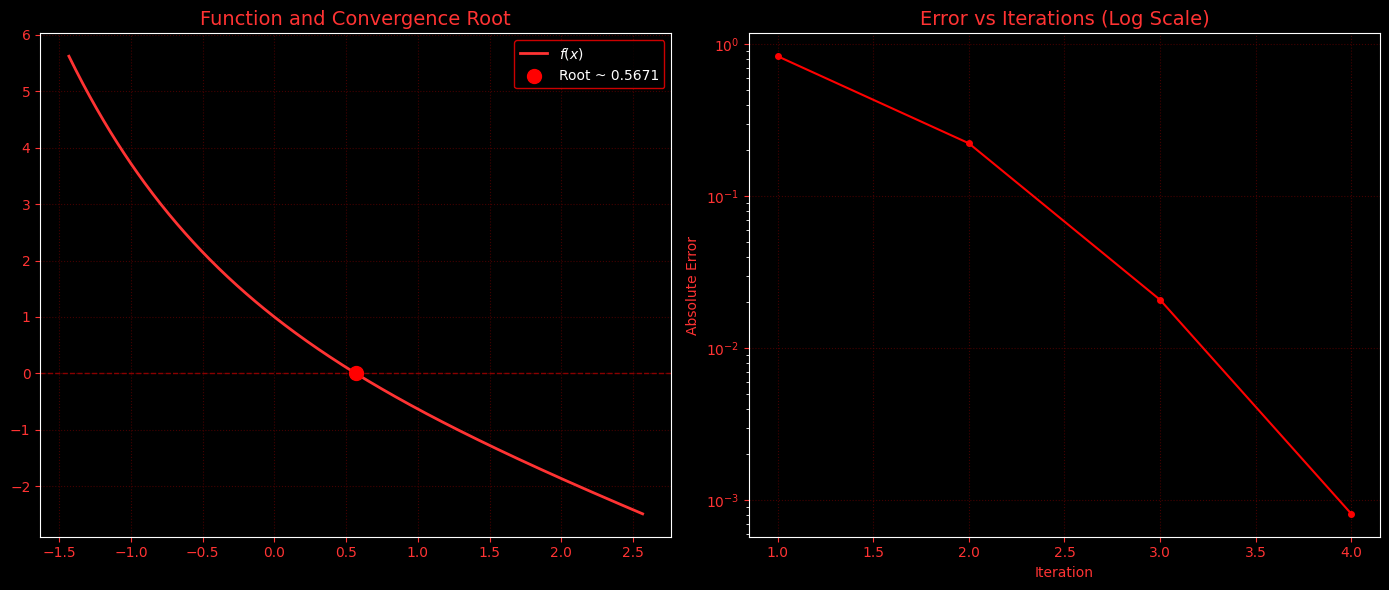

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x): ")
f = lambda x: eval(func_str)

x0 = float(input("Enter initial guess (x0): "))
x1 = float(input("Enter initial guess (x1): "))
tol = float(input("Enter error tolerance: "))
max_iter = int(input("Enter maximum iterations: "))

iterations = []
root_estimates = []
errors = []

print(f"\n{'Iter':<5}{'x_{n-1}':<15}{'x_n':<15}{'x_{n+1}':<15}{'f(x_{n+1})':<15}")
print("-" * 65)

converged = False
for i in range(1, max_iter + 1):
    denom = f(x1) - f(x0)
    if abs(denom) < 1e-15:
        print("\n[Error]: Division by zero encountered due to matching functional values.")
        break

    # Secant Update Equation
    x2 = x1 - (f(x1) * (x1 - x0)) / denom
    fx2 = f(x2)
    err = abs(x2 - x1)

    iterations.append(i)
    root_estimates.append(x2)
    errors.append(err)

    print(f"{i:<5}{x0:<15.6f}{x1:<15.6f}{x2:<15.6f}{fx2:<15.6f}")

    if abs(fx2) < tol or err < tol:
        print(f"\nConvergence achieved at iteration {i}. Estimated Root: {x2:.6f}")
        converged = True
        break

    x0 = x1
    x1 = x2
else:
    if not converged:
        print("\nReached maximum iterations without achieving formal convergence.")

# Visualization
if len(root_estimates) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='#000000')

    ax1.set_facecolor('#000000')
    x_vals = np.linspace(root_estimates[-1] - 2, root_estimates[-1] + 2, 500)
    ax1.plot(x_vals, f(x_vals), color='#FF3333', linewidth=2, label='$f(x)$')
    ax1.axhline(0, color='#880000', linestyle='--', linewidth=1)
    ax1.scatter(root_estimates[-1], f(root_estimates[-1]), color='#FF0000', s=100, zorder=5, label=f'Root ~ {root_estimates[-1]:.4f}')
    ax1.set_title("Function and Convergence Root", color='#FF3333', fontsize=14)
    ax1.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax1.tick_params(colors='#FF3333')
    ax1.legend(facecolor='#000000', edgecolor='#FF0000')

    ax2.set_facecolor('#000000')
    ax2.plot(iterations, errors, color='#FF0000', marker='o', markersize=4)
    ax2.set_yscale('log')
    ax2.set_title("Error vs Iterations (Log Scale)", color='#FF3333', fontsize=14)
    ax2.set_xlabel("Iteration", color='#FF3333')
    ax2.set_ylabel("Absolute Error", color='#FF3333')
    ax2.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax2.tick_params(colors='#FF3333')

    plt.tight_layout()
    plt.show()

###Experiment 3: Advanced Root-Finding Methods

###3.1  Newton–Raphson Method

###Algorithm Logic

The Newton–Raphson Method converges rapidly using local tangent lines. Given an initial guess $x_0$, the subsequent approximations are computed using the function $f(x)$ and its first derivative $f'(x)$ via:$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

Enter the function f(x): x*2-5
Enter its derivative f'(x): 2
Enter initial guess (x0): 2
Enter error tolerance: 0.00001
Enter maximum iterations: 24

Iter x_n            f(x_n)         f'(x_n)        Absolute Error 
----------------------------------------------------------------------
1    2.000000       -1.000000      2.000000       0.500000       

Convergence achieved at iteration 1. Estimated Root: 2.500000


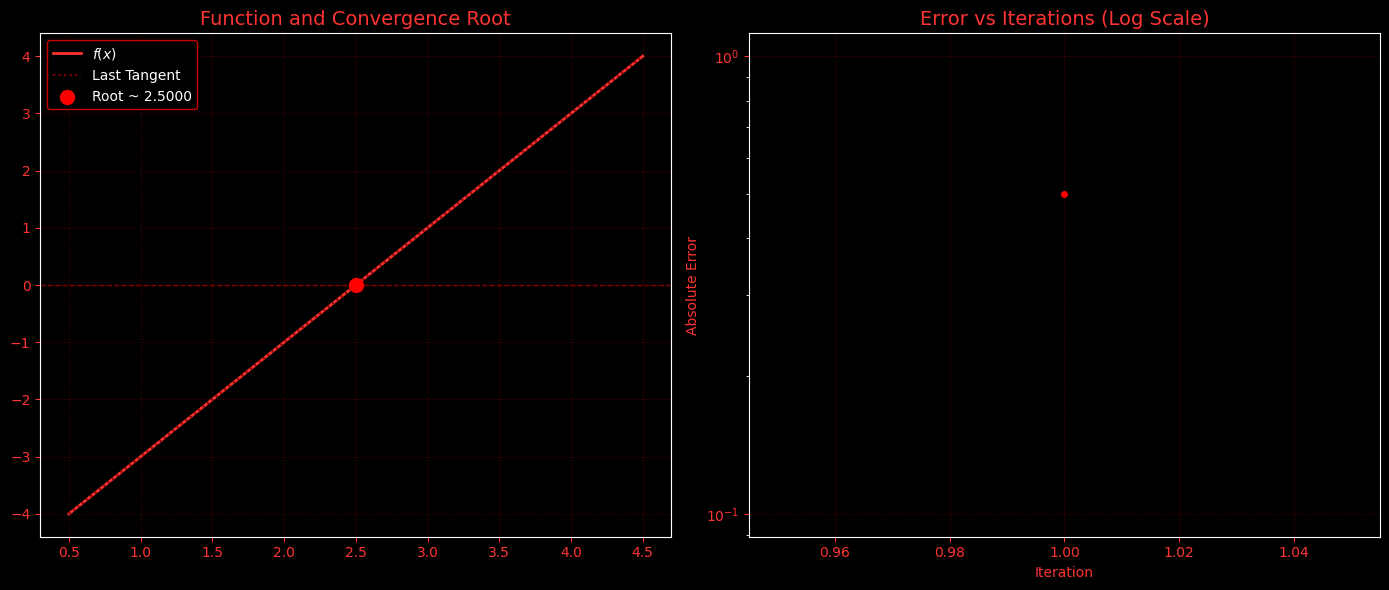

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x): ")
dfunc_str = input("Enter its derivative f'(x): ")

f = lambda x: eval(func_str)
df = lambda x: eval(dfunc_str)

x0 = float(input("Enter initial guess (x0): "))
tol = float(input("Enter error tolerance: "))
max_iter = int(input("Enter maximum iterations: "))

iterations = []
root_estimates = []
errors = []

print(f"\n{'Iter':<5}{'x_n':<15}{'f(x_n)':<15}{'f\'(x_n)':<15}{'Absolute Error':<15}")
print("-" * 70)

x_current = x0
converged = False

for i in range(1, max_iter + 1):
    fx = f(x_current)
    dfx = df(x_current)

    # Avoid division by zero
    if abs(dfx) < 1e-15:
        print("\n[Error]: Derivative is zero. Tangent line is parallel to the x-axis.")
        break

    x_next = x_current - fx / dfx
    err = abs(x_next - x_current)

    iterations.append(i)
    root_estimates.append(x_next)
    errors.append(err)

    print(f"{i:<5}{x_current:<15.6f}{fx:<15.6f}{dfx:<15.6f}{err:<15.6f}")

    if abs(f(x_next)) < tol or err < tol:
        print(f"\nConvergence achieved at iteration {i}. Estimated Root: {x_next:.6f}")
        converged = True
        break

    x_current = x_next
else:
    if not converged:
        print("\nReached maximum iterations without achieving formal convergence.")

# 2. Visualization
if len(root_estimates) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='#000000')

    # Left Plot: Tangent convergence sequence
    ax1.set_facecolor('#000000')
    final_root = root_estimates[-1]
    x_vals = np.linspace(final_root - 2, final_root + 2, 500)
    ax1.plot(x_vals, f(x_vals), color='#FF3333', linewidth=2, label='$f(x)$')
    ax1.axhline(0, color='#880000', linestyle='--', linewidth=1)

    # Plotting the final tangent line step for visual effect
    x_t = root_estimates[-2] if len(root_estimates) > 1 else x0
    y_t = f(x_t)
    tangent_line = df(x_t) * (x_vals - x_t) + y_t
    ax1.plot(x_vals, tangent_line, color='#880000', linestyle=':', label='Last Tangent')

    ax1.scatter(final_root, f(final_root), color='#FF0000', s=100, zorder=5, label=f'Root ~ {final_root:.4f}')
    ax1.set_title("Function and Convergence Root", color='#FF3333', fontsize=14)
    ax1.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax1.tick_params(colors='#FF3333')
    ax1.legend(facecolor='#000000', edgecolor='#FF0000')

    # Right Plot: Logarithmic Error decay
    ax2.set_facecolor('#000000')
    ax2.plot(iterations, errors, color='#FF0000', marker='o', markersize=4)
    ax2.set_yscale('log')
    ax2.set_title("Error vs Iterations (Log Scale)", color='#FF3333', fontsize=14)
    ax2.set_xlabel("Iteration", color='#FF3333')
    ax2.set_ylabel("Absolute Error", color='#FF3333')
    ax2.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax2.tick_params(colors='#FF3333')

    plt.tight_layout()
    plt.show()

###3.2 Generalized Newton’s Method

### Mathematical Logic

When a function $f(x)$ has a repeated root (a root with multiplicity $m > 1$), its value and its derivatives up to $m-1$ are zero at that root:$$f(r) = f'(r) = f''(r) = \dots = f^{(m-1)}(r) = 0$$Because the derivative $f'(x)$ approaches zero near the root, the standard Newton-Raphson method slows down from quadratic convergence to slow linear convergence. To fix this, we scale the correction step by the multiplicity $m$.The iterative update formula is defined as:$$x_{n+1} = x_n - m \frac{f(x_n)}{f'(x_n)}$$

Enter the function f(x): 3*x2 - 10*x + 8
Enter its derivative f'(x): 6*x-10
Enter the multiplicity of the root (m): 2
Enter initial guess (x0): 0.25
Enter error tolerance: 1e-5
Enter maximum iterations: 20

Iter x_n            f(x_n)         f'(x_n)        Absolute Error 
----------------------------------------------------------------------
1    0.250000       7.201420       -8.500000      1.694452       
2    1.944452       -9.743098      1.666711       11.691406      
3    13.635857      -126.657154    71.815145      3.527310       
4    17.163168      -161.930258    92.979007      3.483157       
5    20.646325      -196.761832    113.877952     3.455662       
6    24.101987      -231.318448    134.611921     3.436820       
7    27.538807      -265.686645    155.232839     3.423073       
8    30.961879      -299.917372    175.771275     3.412587       
9    34.374466      -334.043240    196.246796     3.404318       
10   37.778784      -368.086419    216.672704     3.397626    

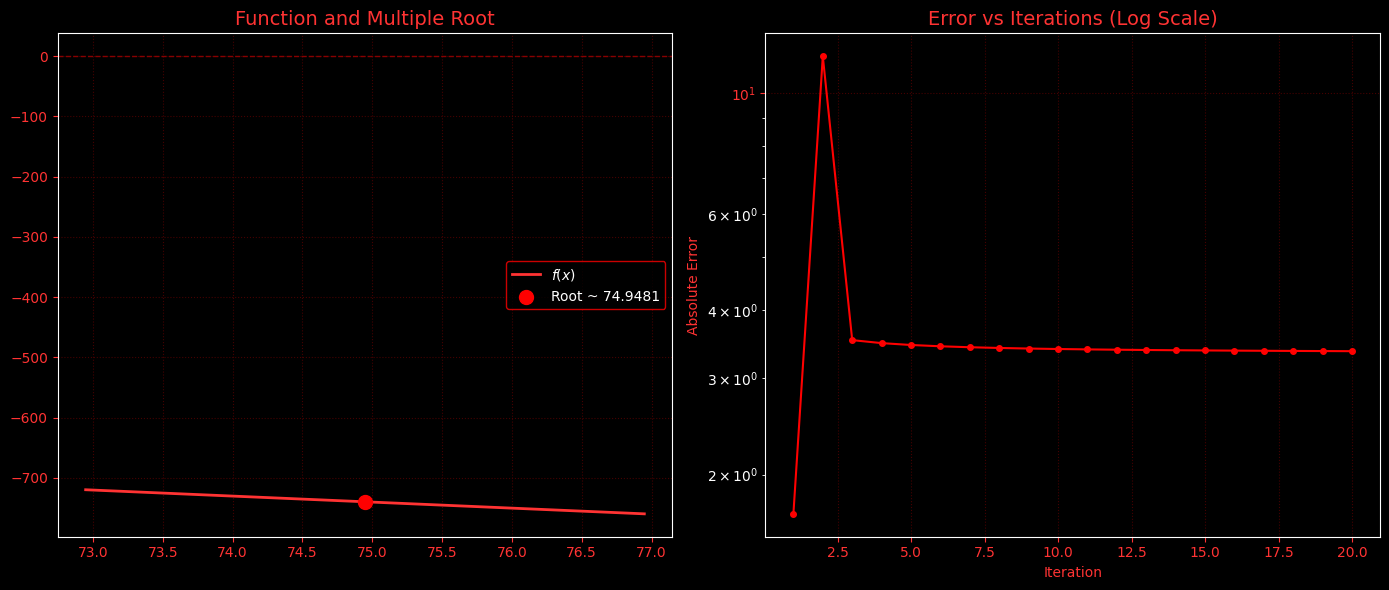

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x): ")
dfunc_str = input("Enter its derivative f'(x): ")
m = int(input("Enter the multiplicity of the root (m): "))

f = lambda x: eval(func_str)
df = lambda x: eval(dfunc_str)

x0 = float(input("Enter initial guess (x0): "))
tol = float(input("Enter error tolerance: "))
max_iter = int(input("Enter maximum iterations: "))

iterations = []
root_estimates = []
errors = []

print(f"\n{'Iter':<5}{'x_n':<15}{'f(x_n)':<15}{'f\'(x_n)':<15}{'Absolute Error':<15}")
print("-" * 70)

x_current = x0
converged = False

for i in range(1, max_iter + 1):
    fx = f(x_current)
    dfx = df(x_current)

    if abs(dfx) < 1e-15:
        print("\n[Error]: Derivative is zero. Cannot proceed.")
        break

    # Generalized step optimization factor using multiplicity m
    x_next = x_current - m * (fx / dfx)
    err = abs(x_next - x_current)

    iterations.append(i)
    root_estimates.append(x_next)
    errors.append(err)

    print(f"{i:<5}{x_current:<15.6f}{fx:<15.6f}{dfx:<15.6f}{err:<15.6f}")

    if abs(f(x_next)) < tol or err < tol:
        print(f"\nConvergence achieved at iteration {i}. Estimated Root: {x_next:.6f}")
        converged = True
        break

    x_current = x_next
else:
    if not converged:
        print("\nReached maximum iterations without achieving formal convergence.")

# 2. Visualization Layout
if len(root_estimates) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='#000000')

    ax1.set_facecolor('#000000')
    final_root = root_estimates[-1]
    x_vals = np.linspace(final_root - 2, final_root + 2, 500)
    ax1.plot(x_vals, f(x_vals), color='#FF3333', linewidth=2, label='$f(x)$')
    ax1.axhline(0, color='#880000', linestyle='--', linewidth=1)
    ax1.scatter(root_estimates[-1], f(root_estimates[-1]), color='#FF0000', s=100, zorder=5, label=f'Root ~ {final_root:.4f}')
    ax1.set_title("Function and Multiple Root", color='#FF3333', fontsize=14)
    ax1.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax1.tick_params(colors='#FF3333')
    ax1.legend(facecolor='#000000', edgecolor='#FF0000')

    ax2.set_facecolor('#000000')
    ax2.plot(iterations, errors, color='#FF0000', marker='o', markersize=4)
    ax2.set_yscale('log')
    ax2.set_title("Error vs Iterations (Log Scale)", color='#FF3333', fontsize=14)
    ax2.set_xlabel("Iteration", color='#FF3333')
    ax2.set_ylabel("Absolute Error", color='#FF3333')
    ax2.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax2.tick_params(colors='#FF3333')

    plt.tight_layout()
    plt.show()

#Experiment 4: Finite Differences Foundations
###4.1 Forward Difference
###4.2 Backward Difference
###4.3 Central Difference


#Algorithm Logic
Finite differences approximate the derivative of a continuous function $f(x)$ at a specific point $x$ using discrete data points separated by a small step size $h$.


Forward Difference Method (First-Order Accurate $O(h)$): Approximates the slope using the target point and the next point ahead.$$f'(x) \approx \frac{f(x + h) - f(x)}{h}$$Backward Difference Method (First-Order Accurate $O(h)$): Approximates the slope using the target point and the previous point behind.$$f'(x) \approx \frac{f(x) - f(x - h)}{h}$$Central Difference Method (Second-Order Accurate $O(h^2)$): Approximates the slope using the points symmetrically ahead and behind the target point, yielding higher accuracy.$$f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}$$

Enter the function f(x): np.sin(x)
Enter the point x at which to evaluate the derivative: 1.02547
Enter the step size h: 1.2

Forward Difference Approximation: -0.05142617
Estimated Absolute Error: 0.57012336


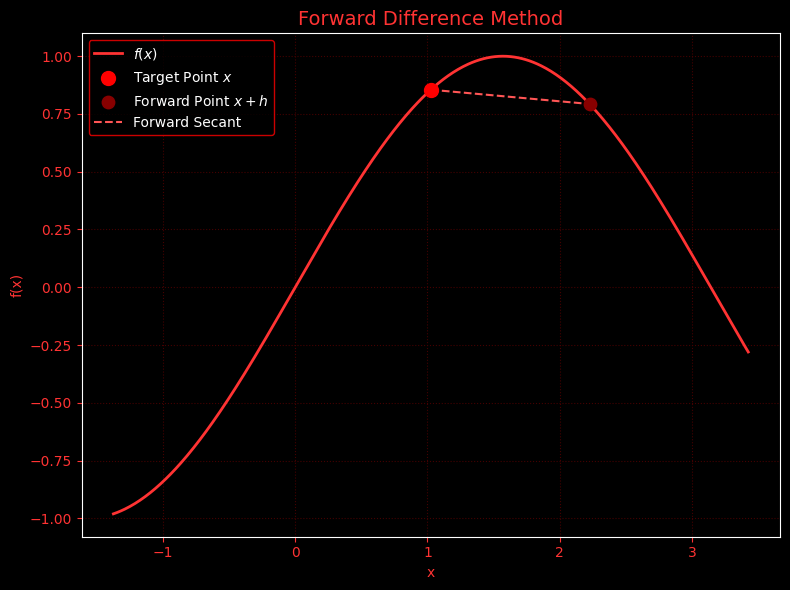

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x): ")
f = lambda x: eval(func_str)

x_target = float(input("Enter the point x at which to evaluate the derivative: "))
h = float(input("Enter the step size h: "))

# 2. Forward Difference Calculation
f_forward = (f(x_target + h) - f(x_target)) / h

# Baseline comparison against a near-exact numerical derivative
h_true = 1e-9
true_derivative = (f(x_target + h_true) - f(x_target - h_true)) / (2 * h_true)
err_forward = abs(f_forward - true_derivative)

print(f"\nForward Difference Approximation: {f_forward:.8f}")
print(f"Estimated Absolute Error: {err_forward:.8f}")

# 3. Visualization
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#000000')
ax.set_facecolor('#000000')

x_vals = np.linspace(x_target - 2*h, x_target + 2*h, 500)
ax.plot(x_vals, f(x_vals), color='#FF3333', linewidth=2, label='$f(x)$')

# Plot Points and Secant Line
ax.scatter(x_target, f(x_target), color='#FF0000', s=100, zorder=5, label='Target Point $x$')
ax.scatter(x_target + h, f(x_target + h), color='#880000', s=80, zorder=4, label='Forward Point $x+h$')
ax.plot([x_target, x_target + h], [f(x_target), f(x_target + h)], color='#FF5555', linestyle='--', linewidth=1.5, label='Forward Secant')

ax.set_title("Forward Difference Method", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("f(x)", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000')

plt.tight_layout()
plt.show()

Enter the function f(x): np.cos(x)
Enter the point x at which to evaluate the derivative: 1.20145
Enter the step size h: 1.8

Backward Difference Approximation: -0.25841531
Estimated Absolute Error: 0.67414830


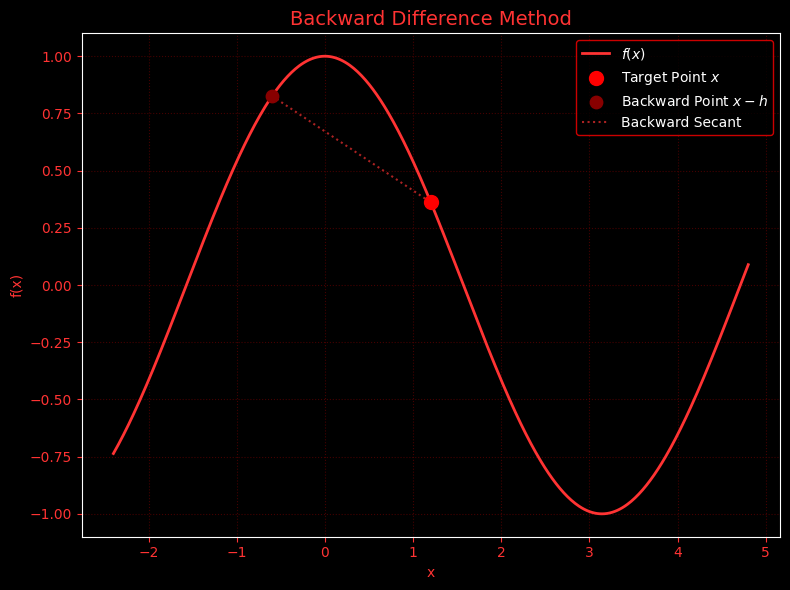

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x): ")
f = lambda x: eval(func_str)

x_target = float(input("Enter the point x at which to evaluate the derivative: "))
h = float(input("Enter the step size h: "))

# 2. Backward Difference Calculation
f_backward = (f(x_target) - f(x_target - h)) / h

h_true = 1e-9
true_derivative = (f(x_target + h_true) - f(x_target - h_true)) / (2 * h_true)
err_backward = abs(f_backward - true_derivative)

print(f"\nBackward Difference Approximation: {f_backward:.8f}")
print(f"Estimated Absolute Error: {err_backward:.8f}")

# 3. Visualization
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#000000')
ax.set_facecolor('#000000')

x_vals = np.linspace(x_target - 2*h, x_target + 2*h, 500)
ax.plot(x_vals, f(x_vals), color='#FF3333', linewidth=2, label='$f(x)$')

# Plot Points and Secant Line
ax.scatter(x_target, f(x_target), color='#FF0000', s=100, zorder=5, label='Target Point $x$')
ax.scatter(x_target - h, f(x_target - h), color='#880000', s=80, zorder=4, label='Backward Point $x-h$')
ax.plot([x_target - h, x_target], [f(x_target - h), f(x_target)], color='#AA2222', linestyle=':', linewidth=1.5, label='Backward Secant')

ax.set_title("Backward Difference Method", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("f(x)", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000')

plt.tight_layout()
plt.show()

Enter the function f(x): np.tan(x)
Enter the point x at which to evaluate the derivative: -1.024
Enter the step size h: 2

Central Difference Approximation: 0.34000128
Estimated Absolute Error: 3.35888770


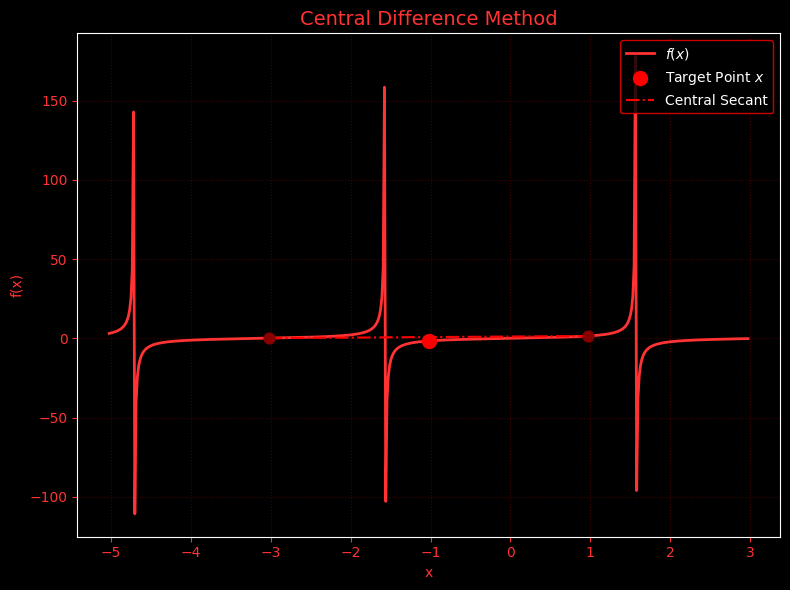

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x): ")
f = lambda x: eval(func_str)

x_target = float(input("Enter the point x at which to evaluate the derivative: "))
h = float(input("Enter the step size h: "))

# 2. Central Difference Calculation
f_central = (f(x_target + h) - f(x_target - h)) / (2 * h)

h_true = 1e-9
true_derivative = (f(x_target + h_true) - f(x_target - h_true)) / (2 * h_true)
err_central = abs(f_central - true_derivative)

print(f"\nCentral Difference Approximation: {f_central:.8f}")
print(f"Estimated Absolute Error: {err_central:.8f}")

# 3. Visualization
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#000000')
ax.set_facecolor('#000000')

x_vals = np.linspace(x_target - 2*h, x_target + 2*h, 500)
ax.plot(x_vals, f(x_vals), color='#FF3333', linewidth=2, label='$f(x)$')

# Plot Points and Secant Line
ax.scatter(x_target, f(x_target), color='#FF0000', s=100, zorder=5, label='Target Point $x$')
ax.scatter(x_target - h, f(x_target - h), color='#880000', s=60, zorder=4)
ax.scatter(x_target + h, f(x_target + h), color='#880000', s=60, zorder=4)
ax.plot([x_target - h, x_target + h], [f(x_target - h), f(x_target + h)], color='#FF0000', linestyle='-.', linewidth=1.5, label='Central Secant')

ax.set_title("Central Difference Method", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("f(x)", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000')

plt.tight_layout()
plt.show()

#Experiment 5: Polynomial Interpolation (Part I)

##5.1 Newton’s Forward Interpolation

##Algorithm Logic

Newton’s Forward Interpolation is used to find a value of $y$ corresponding to a given $x$ near the beginning of a data set.


###Forward Difference Table:

First, we construct a forward difference table where the first column contains the $y$ values ($y_0, y_1, \dots$). Subsequent columns are calculated as:$$\Delta y_i = y_{i+1} - y_i$$$$\Delta^2 y_i = \Delta y_{i+1} - \Delta y_i$$and so on.Interpolation Formula: The value of $y$ at a given $x$ is calculated using the formula:$$y(x) = y_0 + u\Delta y_0 + \frac{u(u-1)}{2!}\Delta^2 y_0 + \frac{u(u-1)(u-2)}{3!}\Delta^3 y_0 + \dots$$where $u$ represents the fractional step from the initial point:$$u = \frac{x - x_0}{h}$$and $h$ is the constant difference between consecutive $x$ values ($h = x_1 - x_0$).

Enter x values separated by spaces: 10 20 30 40
Enter corresponding y values separated by spaces: 1.1414 1.2828 1.4142 1.5707
Enter the interpolation point (x) to estimate y: 32

--- Forward Difference Table ---
x         y           Δ^1y_0:<12Δ^2y_0:<12Δ^3y_0:<12
----------------------------------------------------------
10.0000   1.1414      0.1414      -0.0100     0.0351      
20.0000   1.2828      0.1314      0.0251      
30.0000   1.4142      0.1565      
40.0000   1.5707      
----------------------------------------------------------
Interpolated value at x = 32.0000 is y = 1.442369


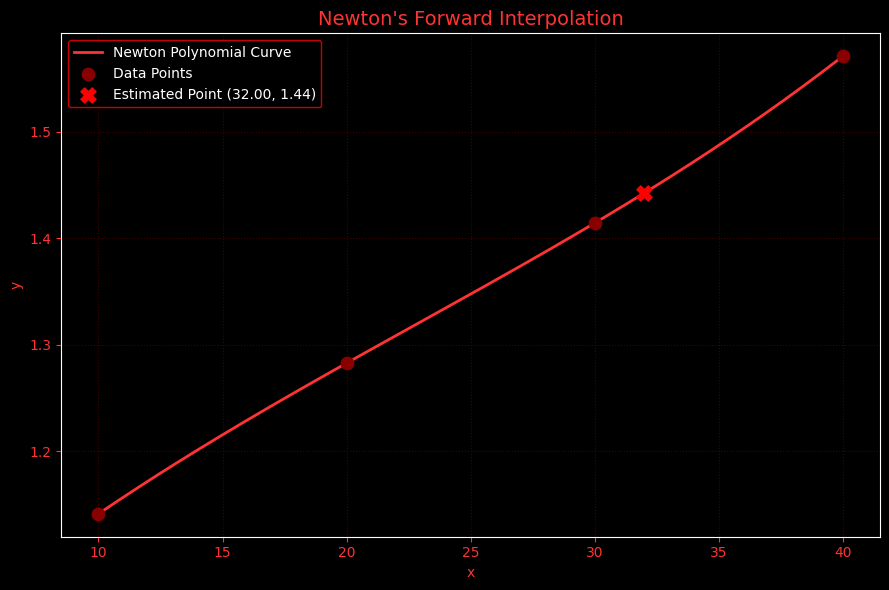

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

x_target = float(input("Enter the interpolation point (x) to estimate y: "))

n = len(x_pts)
h = x_pts[1] - x_pts[0]

# 2. Construct Forward Difference Table
diff_table = np.zeros((n, n))
diff_table[:, 0] = y_pts

for j in range(1, n):
    for i in range(n - j):
        diff_table[i, j] = diff_table[i + 1, j - 1] - diff_table[i, j - 1]

# Display Table
print("\n--- Forward Difference Table ---")
header = f"{'x':<10}{'y':<12}" + "".join([f"Δ^{j}y_0:<12" for j in range(1, n)])
print(header)
print("-" * (10 + 12 * n))
for i in range(n):
    row_str = f"{x_pts[i]:<10.4f}"
    for j in range(n - i):
        row_str += f"{diff_table[i, j]:<12.4f}"
    print(row_str)

# 3. Compute Interpolation
u = (x_target - x_pts[0]) / h
y_target = diff_table[0, 0]
u_term = 1.0

for j in range(1, n):
    u_term *= (u - (j - 1))
    y_target += (u_term * diff_table[0, j]) / math.factorial(j)

print("-" * (10 + 12 * n))
print(f"Interpolated value at x = {x_target:.4f} is y = {y_target:.6f}")

# 4. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate smooth evaluation curve using the polynomial logic across the domain
x_dense = np.linspace(min(x_pts), max(x_pts), 500)
y_dense = []

for x_val in x_dense:
    u_dense = (x_val - x_pts[0]) / h
    y_val = diff_table[0, 0]
    u_term_dense = 1.0
    for j in range(1, n):
        u_term_dense *= (u_dense - (j - 1))
        y_val += (u_term_dense * diff_table[0, j]) / math.factorial(j)
    y_dense.append(y_val)

# Plot dense interpolating polynomial curve
ax.plot(x_dense, y_dense, color='#FF3333', linewidth=2, label='Newton Polynomial Curve')

# Plot original experimental dataset coordinates
ax.scatter(x_pts, y_pts, color='#880000', s=80, zorder=4, label='Data Points')

# Highlight interpolated query coordinate target
ax.scatter(x_target, y_target, color='#FF0000', s=120, zorder=5, marker='X', label=f'Estimated Point ({x_target:.2f}, {y_target:.2f})')

ax.set_title("Newton's Forward Interpolation", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

##5.2 Newton’s Backward Interpolation!

##Algorithm Logic

Newton’s Backward Interpolation uses backward differences to approximate the value of $y$ for a given $x$ near the end of a data sequence.

Backward Difference Table: We construct a difference table where the first column contains the given $y$ values. Subsequent columns represent backward differences calculated as:$$\nabla y_i = y_i - y_{i-1}$$$$\nabla^2 y_i = \nabla y_i - \nabla y_{i-1}$$The algorithm extracts values from the bottom row of this table ($y_n, \nabla y_n, \nabla^2 y_n, \dots$).Interpolation Formula: The value of $y$ at a given $x$ is computed using the formula:$$y(x) = y_n + v\nabla y_n + \frac{v(v+1)}{2!}\nabla^2 y_n + \frac{v(v+1)(v+2)}{3!}\nabla^3 y_n + \dots$$where $v$ is the fractional distance step from the final point:$$v = \frac{x - x_n}{h}$$and $h$ is the constant spacing between the $x$ values.

Enter x values separated by spaces: 24 26 28 30
Enter corresponding y values separated by spaces: 1.2 3.2 4.8 5.3 
Enter the interpolation point (x) to estimate y: 25

--- Backward Difference Table ---
x         y           ∇^1y_n:<12∇^2y_n:<12∇^3y_n:<12
----------------------------------------------------------
24.0000   1.2000      
26.0000   3.2000      2.0000      
28.0000   4.8000      1.6000      -0.4000     
30.0000   5.3000      0.5000      -1.1000     -0.7000     
----------------------------------------------------------
Interpolated value at x = 25.0000 is y = 2.206250


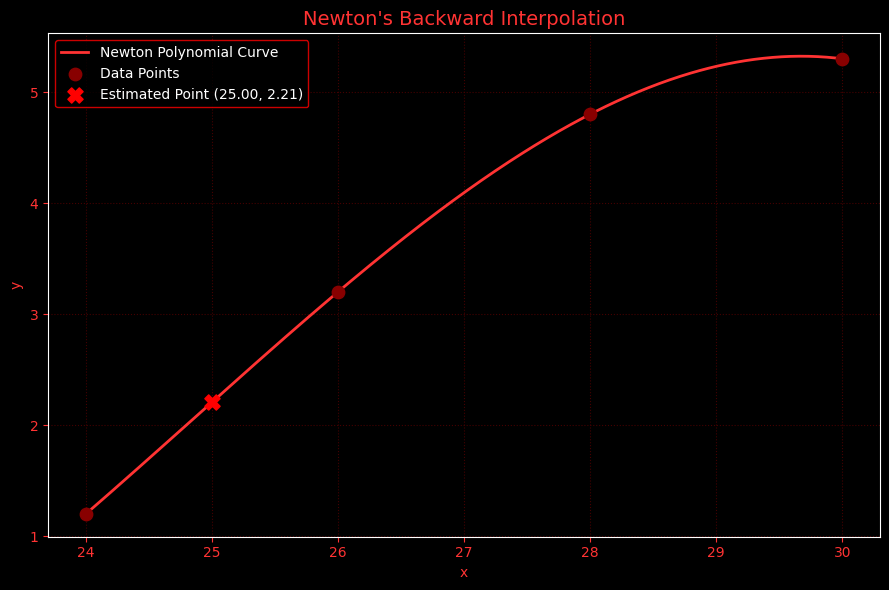

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

x_target = float(input("Enter the interpolation point (x) to estimate y: "))

n = len(x_pts)
h = x_pts[1] - x_pts[0]

# 2. Construct Backward Difference Table
diff_table = np.zeros((n, n))
diff_table[:, 0] = y_pts

for j in range(1, n):
    for i in range(n - 1, j - 1, -1):
        diff_table[i, j] = diff_table[i, j - 1] - diff_table[i - 1, j - 1]

# Display Table
print("\n--- Backward Difference Table ---")
header = f"{'x':<10}{'y':<12}" + "".join([f"∇^{j}y_n:<12" for j in range(1, n)])
print(header)
print("-" * (10 + 12 * n))
for i in range(n):
    row_str = f"{x_pts[i]:<10.4f}"
    for j in range(i + 1):
        row_str += f"{diff_table[i, j]:<12.4f}"
    print(row_str)

# 3. Compute Interpolation (Using base entries from the bottom row)
v = (x_target - x_pts[-1]) / h
y_target = diff_table[-1, 0]
v_term = 1.0

for j in range(1, n):
    v_term *= (v + (j - 1))
    y_target += (v_term * diff_table[-1, j]) / math.factorial(j)

print("-" * (10 + 12 * n))
print(f"Interpolated value at x = {x_target:.4f} is y = {y_target:.6f}")

# 4. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate smooth evaluation curve across the domain
x_dense = np.linspace(min(x_pts), max(x_pts), 500)
y_dense = []

for x_val in x_dense:
    v_dense = (x_val - x_pts[-1]) / h
    y_val = diff_table[-1, 0]
    v_term_dense = 1.0
    for j in range(1, n):
        v_term_dense *= (v_dense + (j - 1))
        y_val += (v_term_dense * diff_table[-1, j]) / math.factorial(j)
    y_dense.append(y_val)

# Plot dense interpolating polynomial curve
ax.plot(x_dense, y_dense, color='#FF3333', linewidth=2, label='Newton Polynomial Curve')

# Plot original experimental dataset coordinates
ax.scatter(x_pts, y_pts, color='#880000', s=80, zorder=4, label='Data Points')

# Highlight interpolated query coordinate target
ax.scatter(x_target, y_target, color='#FF0000', s=120, zorder=5, marker='X', label=f'Estimated Point ({x_target:.2f}, {y_target:.2f})')

ax.set_title("Newton's Backward Interpolation", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

###Experiment 6: Central Interpolation

##6.1 Gauss Forward Interpolation

##Algorithm Logic


Central interpolation methods are optimized for estimating values near the middle of an equally spaced dataset. To simplify the indexing, we designate a central base point as $x_0$ and assign integer offsets relative to it ($\dots, -2, -1, 0, 1, 2, \dots$).


Origin Transformation: We calculate the normalized step variable $u$ measured from the chosen origin $x_0$:$$u = \frac{x - x_0}{h}$$where $h$ represents the constant spacing interval ($h = x_1 - x_0$).


Gauss Forward Formula: This method uses differences that trend downward across the central difference table. The interpolation polynomial is constructed as:$$y(x) = y_0 + u\Delta y_0 + \frac{u(u-1)}{2!}\Delta^2 y_{-1} + \frac{(u+1)u(u-1)}{3!}\Delta^3 y_{-1} + \frac{(u+1)u(u-1)(u-2)}{4!}\Delta^4 y_{-2} + \dots$$

Enter x values separated by spaces: 29 31 33 35 37 39
Enter corresponding y values separated by spaces: 2.9 3.1 3.3 3.5 3.7 3.9
Enter the interpolation point (x) to estimate y: 32

--- Central Difference Table (Standard Index Layout) ---
x         y           Δ^1y:<12Δ^2y:<12Δ^3y:<12Δ^4y:<12Δ^5y:<12
----------------------------------------------------------------------------------
29.0000   2.9000      0.2000      -0.0000     0.0000      -0.0000     0.0000      
31.0000   3.1000      0.2000      0.0000      -0.0000     0.0000       <-- [Origin x0]
33.0000   3.3000      0.2000      0.0000      -0.0000     
35.0000   3.5000      0.2000      -0.0000     
37.0000   3.7000      0.2000      
39.0000   3.9000      
----------------------------------------------------------------------------------
Interpolated value at x = 32.0000 is y = 3.200000


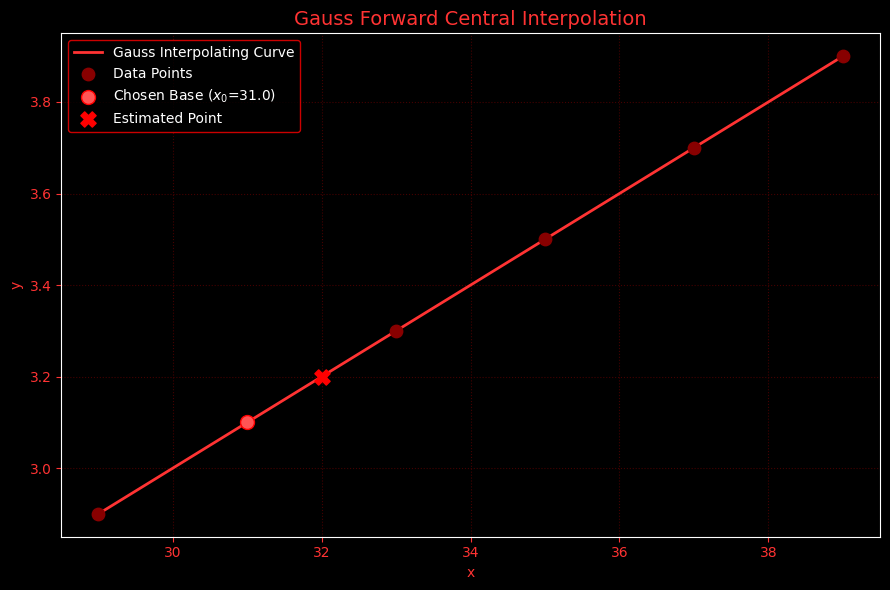

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

x_target = float(input("Enter the interpolation point (x) to estimate y: "))

n = len(x_pts)
h = x_pts[1] - x_pts[0]

# 2. Find Central Base Point Index (x0)
# Locate the closest data point that is less than or equal to x_target
x0_idx = 0
for i in range(n):
    if x_pts[i] <= x_target:
        x0_idx = i

# 3. Construct the Central Difference Table
diff_table = np.zeros((n, n))
diff_table[:, 0] = y_pts

for j in range(1, n):
    for i in range(n - j):
        diff_table[i, j] = diff_table[i + 1, j - 1] - diff_table[i, j - 1]

# Display Table
print("\n--- Central Difference Table (Standard Index Layout) ---")
header = f"{'x':<10}{'y':<12}" + "".join([f"Δ^{j}y:<12" for j in range(1, n)])
print(header)
print("-" * (10 + 12 * n))
for i in range(n):
    row_str = f"{x_pts[i]:<10.4f}"
    for j in range(n - i):
        row_str += f"{diff_table[i, j]:<12.4f}"
    if i == x0_idx:
        row_str += " <-- [Origin x0]"
    print(row_str)

# 4. Compute Gauss Forward Interpolation
u = (x_target - x_pts[x0_idx]) / h
y_target = diff_table[x0_idx, 0]

u_term = 1.0
current_row = x0_idx

for j in range(1, n):
    # Determine numerator term based on Gauss Forward path progression
    if j % 2 != 0:
        u_term *= (u - (j // 2))
    else:
        u_term *= (u + (j // 2))
        current_row -= 1  # Shift row up for even column differences

    if current_row >= 0 and current_row < n - j:
        y_target += (u_term * diff_table[current_row, j]) / math.factorial(j)
    else:
        break

print("-" * (10 + 12 * n))
print(f"Interpolated value at x = {x_target:.4f} is y = {y_target:.6f}")

# 5. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate smooth evaluation curve
x_dense = np.linspace(min(x_pts), max(x_pts), 500)
y_dense = []

for x_val in x_dense:
    # Find matching base point index for continuous curve plotting
    base_idx = 0
    for i in range(n):
        if x_pts[i] <= x_val:
            base_idx = i

    u_dense = (x_val - x_pts[base_idx]) / h
    y_val = diff_table[base_idx, 0]
    u_term_dense = 1.0
    curr_row_dense = base_idx

    for j in range(1, n):
        if j % 2 != 0:
            u_term_dense *= (u_dense - (j // 2))
        else:
            u_term_dense *= (u_dense + (j // 2))
            curr_row_dense -= 1

        if curr_row_dense >= 0 and curr_row_dense < n - j:
            y_val += (u_term_dense * diff_table[curr_row_dense, j]) / math.factorial(j)
        else:
            break
    y_dense.append(y_val)

ax.plot(x_dense, y_dense, color='#FF3333', linewidth=2, label='Gauss Interpolating Curve')
ax.scatter(x_pts, y_pts, color='#880000', s=80, zorder=4, label='Data Points')
ax.scatter(x_pts[x0_idx], y_pts[x0_idx], color='#FF5555', s=100, edgecolors='#FF0000', zorder=5, label=f'Chosen Base ($x_0$={x_pts[x0_idx]})')
ax.scatter(x_target, y_target, color='#FF0000', s=120, zorder=6, marker='X', label=f'Estimated Point')

ax.set_title("Gauss Forward Central Interpolation", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

##6.2 Gauss Backward Interpolation

##Algorithm Logic

Gauss Backward Interpolation is a central interpolation method optimized for calculating values near the middle of an equally spaced dataset, specifically when the target point lies just before the central base point ($x_0$).

Origin Transformation: We calculate the normalized step variable $u$ measured from the chosen origin $x_0$:$$u = \frac{x - x_0}{h}$$where $h$ is the constant spacing interval.

Gauss Backward Formula: This method utilizes differences that trend upward across the central difference table. The interpolation polynomial is constructed as:$$y(x) = y_0 + u\Delta y_{-1} + \frac{(u+1)u}{2!}\Delta^2 y_{-1} + \frac{(u+1)u(u-1)}{3!}\Delta^3 y_{-2} + \frac{(u+2)(u+1)u(u-1)}{4!}\Delta^4 y_{-2} + \dots$$

Enter x values separated by spaces: 5 12 19 26 33
Enter corresponding y values separated by spaces: 1.2 2.4 3.6 4.8 5.2
Enter the interpolation point (x) to estimate y: 32

--- Central Difference Table (Standard Index Layout) ---
x         y           Δ^1y:<12Δ^2y:<12Δ^3y:<12Δ^4y:<12
----------------------------------------------------------------------
5.0000    1.2000      1.2000      0.0000      -0.0000     -0.8000     
12.0000   2.4000      1.2000      -0.0000     -0.8000     
19.0000   3.6000      1.2000      -0.8000     
26.0000   4.8000      0.4000      
33.0000   5.2000       <-- [Origin x0]
----------------------------------------------------------------------
Interpolated value at x = 32.0000 is y = 5.142857


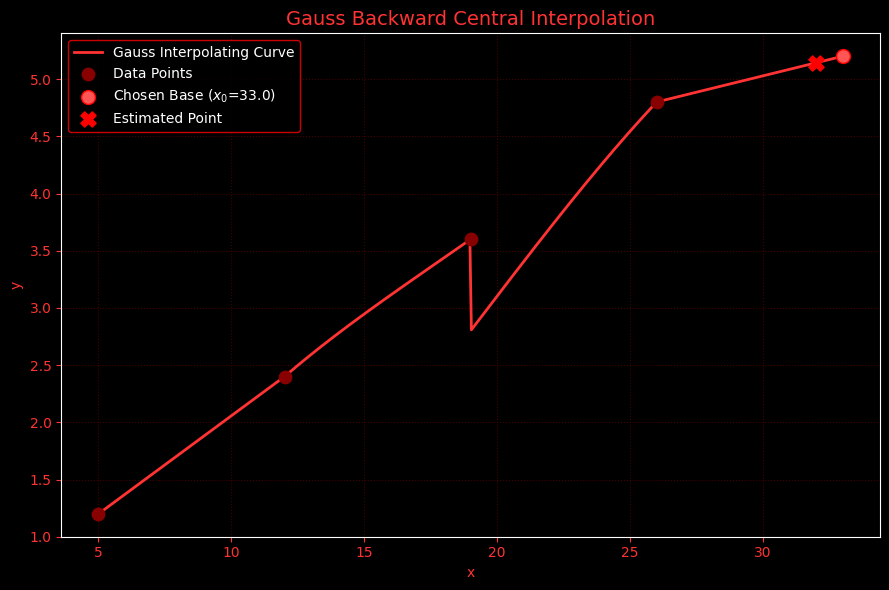

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

x_target = float(input("Enter the interpolation point (x) to estimate y: "))

n = len(x_pts)
h = x_pts[1] - x_pts[0]

# 2. Find Central Base Point Index (x0)
# For Gauss Backward, choose the closest data point that is greater than or equal to x_target
x0_idx = 0
for i in range(n):
    if x_pts[i] >= x_target:
        x0_idx = i
        break

# 3. Construct the Central Difference Table
diff_table = np.zeros((n, n))
diff_table[:, 0] = y_pts

for j in range(1, n):
    for i in range(n - j):
        diff_table[i, j] = diff_table[i + 1, j - 1] - diff_table[i, j - 1]

# Display Table
print("\n--- Central Difference Table (Standard Index Layout) ---")
header = f"{'x':<10}{'y':<12}" + "".join([f"Δ^{j}y:<12" for j in range(1, n)])
print(header)
print("-" * (10 + 12 * n))
for i in range(n):
    row_str = f"{x_pts[i]:<10.4f}"
    for j in range(n - i):
        row_str += f"{diff_table[i, j]:<12.4f}"
    if i == x0_idx:
        row_str += " <-- [Origin x0]"
    print(row_str)

# 4. Compute Gauss Backward Interpolation
u = (x_target - x_pts[x0_idx]) / h
y_target = diff_table[x0_idx, 0]

u_term = 1.0
current_row = x0_idx

for j in range(1, n):
    # Determine numerator term based on Gauss Backward path progression
    if j % 2 != 0:
        u_term *= (u + (j // 2))
        current_row -= 1  # Shift row up for odd column differences
    else:
        u_term *= (u - (j // 2))

    if current_row >= 0 and current_row < n - j:
        y_target += (u_term * diff_table[current_row, j]) / math.factorial(j)
    else:
        break

print("-" * (10 + 12 * n))
print(f"Interpolated value at x = {x_target:.4f} is y = {y_target:.6f}")

# 5. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate smooth evaluation curve
x_dense = np.linspace(min(x_pts), max(x_pts), 500)
y_dense = []

for x_val in x_dense:
    base_idx = 0
    for i in range(n):
        if x_pts[i] >= x_val:
            base_idx = i
            break

    u_dense = (x_val - x_pts[base_idx]) / h
    y_val = diff_table[base_idx, 0]
    u_term_dense = 1.0
    curr_row_dense = base_idx

    for j in range(1, n):
        if j % 2 != 0:
            u_term_dense *= (u_dense + (j // 2))
            curr_row_dense -= 1
        else:
            u_term_dense *= (u_dense - (j // 2))

        if curr_row_dense >= 0 and curr_row_dense < n - j:
            y_val += (u_term_dense * diff_table[curr_row_dense, j]) / math.factorial(j)
        else:
            break
    y_dense.append(y_val)

ax.plot(x_dense, y_dense, color='#FF3333', linewidth=2, label='Gauss Interpolating Curve')
ax.scatter(x_pts, y_pts, color='#880000', s=80, zorder=4, label='Data Points')
ax.scatter(x_pts[x0_idx], y_pts[x0_idx], color='#FF5555', s=100, edgecolors='#FF0000', zorder=5, label=f'Chosen Base ($x_0$={x_pts[x0_idx]})')
ax.scatter(x_target, y_target, color='#FF0000', s=120, zorder=6, marker='X', label=f'Estimated Point')

ax.set_title("Gauss Backward Central Interpolation", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

###Experiment 7: Advanced & Unequal Interpolation

##7.1 Stirling’s Interpolation

##Algorithm Logic

Stirling's Interpolation formula is a central difference method obtained by taking the arithmetic mean of Gauss’s Forward and Backward formulas. It is highly accurate for interpolating values near the center of an equally spaced dataset, specifically when the normalized step value satisfies $-0.25 \le u \le 0.25$.

Normalized Step Factor:$$u = \frac{x - x_0}{h}$$Stirling's Formula:$$y(x) = y_0 + u \left( \frac{\Delta y_0 + \Delta y_{-1}}{2} \right) + \frac{u^2}{2!}\Delta^2 y_{-1} + \frac{u(u^2-1)}{3!} \left( \frac{\Delta^3 y_{-1} + \Delta^3 y_{-2}}{2} \right) + \frac{u^2(u^2-1)}{4!}\Delta^4 y_{-2} + \dots$$

Enter x values separated by spaces: 2 4 6 8 10
Enter corresponding y values separated by spaces: 1.1 1.2 1.3 1.4 1.5
Enter the interpolation point (x) to estimate y: 5

--- Central Difference Table ---
x         y           Δ^1y:<12Δ^2y:<12Δ^3y:<12Δ^4y:<12
----------------------------------------------------------------------
2.0000    1.1000      0.1000      0.0000      -0.0000     0.0000      
4.0000    1.2000      0.1000      -0.0000     0.0000       <-- [Origin x0]
6.0000    1.3000      0.1000      0.0000      
8.0000    1.4000      0.1000      
10.0000   1.5000      
----------------------------------------------------------------------
Interpolated value at x = 5.0000 is y = 1.250000


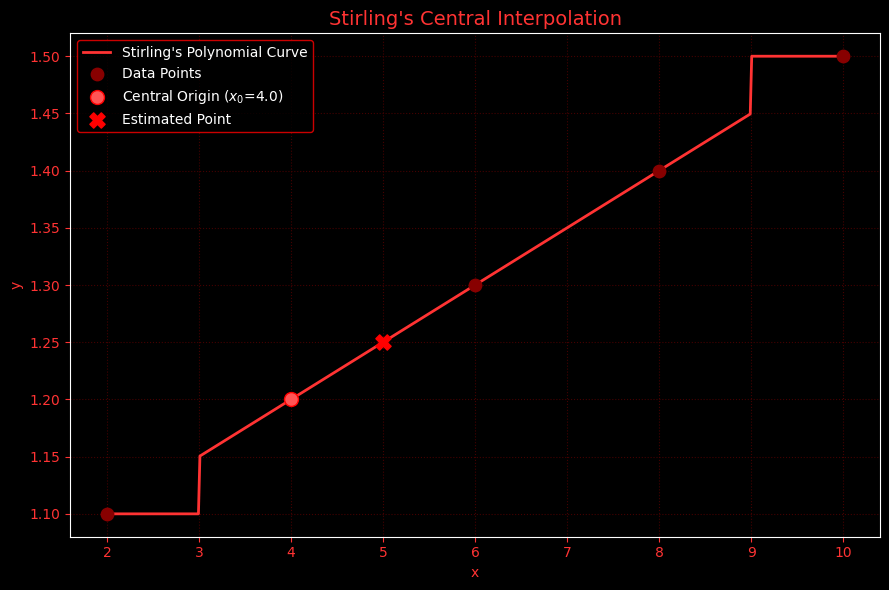

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

x_target = float(input("Enter the interpolation point (x) to estimate y: "))

n = len(x_pts)
h = x_pts[1] - x_pts[0]

# 2. Find Central Base Point Index (x0) - Closest to target
x0_idx = np.argmin(np.abs(x_pts - x_target))

# 3. Construct Central Difference Table
diff_table = np.zeros((n, n))
diff_table[:, 0] = y_pts

for j in range(1, n):
    for i in range(n - j):
        diff_table[i, j] = diff_table[i + 1, j - 1] - diff_table[i, j - 1]

# Display Table
print("\n--- Central Difference Table ---")
header = f"{'x':<10}{'y':<12}" + "".join([f"Δ^{j}y:<12" for j in range(1, n)])
print(header)
print("-" * (10 + 12 * n))
for i in range(n):
    row_str = f"{x_pts[i]:<10.4f}"
    for j in range(n - i):
        row_str += f"{diff_table[i, j]:<12.4f}"
    if i == x0_idx:
        row_str += " <-- [Origin x0]"
    print(row_str)

# 4. Compute Stirling Interpolation
u = (x_target - x_pts[x0_idx]) / h
y_target = diff_table[x0_idx, 0]

# Pre-calculate factor variables
u2 = u * u

# First order term
if x0_idx - 1 >= 0 and x0_idx < n - 1:
    y_target += u * (diff_table[x0_idx, 1] + diff_table[x0_idx - 1, 1]) / 2.0

# Second order term
if x0_idx - 1 >= 0 and x0_idx - 1 < n - 2:
    y_target += (u2 * diff_table[x0_idx - 1, 2]) / math.factorial(2)

# Third order term
if x0_idx - 2 >= 0 and x0_idx - 1 < n - 3:
    y_target += u * (u2 - 1) * (diff_table[x0_idx - 1, 3] + diff_table[x0_idx - 2, 3]) / (2.0 * math.factorial(3))

# Fourth order term
if x0_idx - 2 >= 0 and x0_idx - 2 < n - 4:
    y_target += (u2 * (u2 - 1) * diff_table[x0_idx - 2, 4]) / math.factorial(4)

print("-" * (10 + 12 * n))
print(f"Interpolated value at x = {x_target:.4f} is y = {y_target:.6f}")

# 5. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate smooth evaluation curve across domain
x_dense = np.linspace(min(x_pts), max(x_pts), 500)
y_dense = []

for x_val in x_dense:
    base_idx = np.argmin(np.abs(x_pts - x_val))
    u_d = (x_val - x_pts[base_idx]) / h
    u2_d = u_d * u_d
    y_val = diff_table[base_idx, 0]

    if base_idx - 1 >= 0 and base_idx < n - 1:
        y_val += u_d * (diff_table[base_idx, 1] + diff_table[base_idx - 1, 1]) / 2.0
    if base_idx - 1 >= 0 and base_idx - 1 < n - 2:
        y_val += (u2_d * diff_table[base_idx - 1, 2]) / math.factorial(2)
    if base_idx - 2 >= 0 and base_idx - 1 < n - 3:
        y_val += u_d * (u2_d - 1) * (diff_table[base_idx - 1, 3] + diff_table[base_idx - 2, 3]) / (2.0 * math.factorial(3))
    if base_idx - 2 >= 0 and base_idx - 2 < n - 4:
        y_val += (u2_d * (u2_d - 1) * diff_table[base_idx - 2, 4]) / math.factorial(4)
    y_dense.append(y_val)

ax.plot(x_dense, y_dense, color='#FF3333', linewidth=2, label="Stirling's Polynomial Curve")
ax.scatter(x_pts, y_pts, color='#880000', s=80, zorder=4, label='Data Points')
ax.scatter(x_pts[x0_idx], y_pts[x0_idx], color='#FF5555', s=100, edgecolors='#FF0000', zorder=5, label=f'Central Origin ($x_0$={x_pts[x0_idx]})')
ax.scatter(x_target, y_target, color='#FF0000', s=120, zorder=6, marker='X', label=f'Estimated Point')

ax.set_title("Stirling's Central Interpolation", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

##7.2 Lagrange Interpolation

##Algorithm Logic

Unlike previous methods, Lagrange Interpolation does not require the data points to be equally spaced. It constructs a single polynomial that passes exactly through all given coordinates $(x_i, y_i)$.The interpolated value $y(x)$ is calculated as a weighted sum of all $y_i$ entries:$$y(x) = \sum_{i=0}^{n-1} L_i(x) \cdot y_i$$Where $L_i(x)$ represents the fundamental Lagrange basis coefficients, computed by taking products over all indices except $i$:$$L_i(x) = \prod_{j \neq i} \frac{x - x_j}{x_i - x_j} = \frac{(x - x_0)(x - x_1)\dots(x - x_{i-1})(x - x_{i+1})\dots(x - x_{n-1})}{(x_i - x_0)(x_i - x_1)\dots(x_i - x_{i-1})(x_i - x_{i+1})\dots(x_i - x_{n-1})}$$

Enter x values separated by spaces: 3 6 9 12 15 
Enter corresponding y values separated by spaces: 2.1 3.2 4.5 6.2 5.1
Enter the interpolation point (x) to estimate y: 8

--- Basis Coefficients (L_i) Calculation ---
L_0(8.0000) = -0.028807
L_1(8.0000) = 0.288066
L_2(8.0000) = 0.864198
L_3(8.0000) = -0.144033
L_4(8.0000) = 0.020576
---------------------------------------------
Interpolated value at x = 8.0000 is y = 3.962140


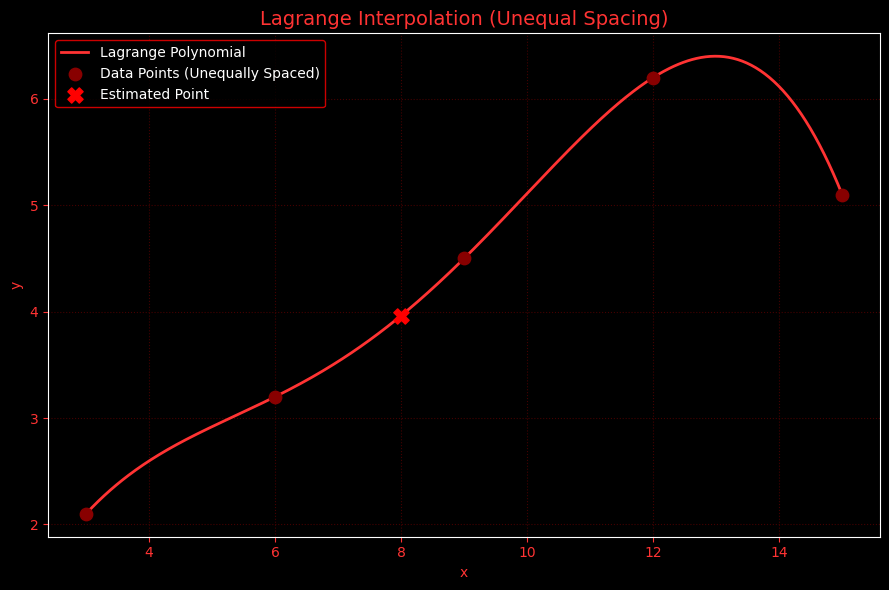

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

x_target = float(input("Enter the interpolation point (x) to estimate y: "))

n = len(x_pts)

# 2. Compute Lagrange Interpolation
y_target = 0.0

print("\n--- Basis Coefficients (L_i) Calculation ---")
for i in range(n):
    term = 1.0
    for j in range(n):
        if i != j:
            term *= (x_target - x_pts[j]) / (x_pts[i] - x_pts[j])

    y_target += term * y_pts[i]
    print(f"L_{i}({x_target:.4f}) = {term:.6f}")

print("-" * 45)
print(f"Interpolated value at x = {x_target:.4f} is y = {y_target:.6f}")

# 3. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate smooth evaluation curve across domain
x_dense = np.linspace(min(x_pts), max(x_pts), 500)
y_dense = []

for x_val in x_dense:
    y_val = 0.0
    for i in range(n):
        term = 1.0
        for j in range(n):
            if i != j:
                term *= (x_val - x_pts[j]) / (x_pts[i] - x_pts[j])
        y_val += term * y_pts[i]
    y_dense.append(y_val)

ax.plot(x_dense, y_dense, color='#FF3333', linewidth=2, label='Lagrange Polynomial')
ax.scatter(x_pts, y_pts, color='#880000', s=80, zorder=4, label='Data Points (Unequally Spaced)')
ax.scatter(x_target, y_target, color='#FF0000', s=120, zorder=5, marker='X', label=f'Estimated Point')

ax.set_title("Lagrange Interpolation (Unequal Spacing)", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

#Experiment 8: Divided Differences & Inverse Interpolation

##8.1 Newton’s Divided Difference Method

##Algorithm Logic

Newton’s Divided Difference Method is another powerful tool designed for unequally spaced datasets. It constructs a polynomial approximation by computing successive divided differences.Divided Difference Calculations:First-order divided differences:$$f[x_0, x_1] = \frac{y_1 - y_0}{x_1 - x_0}$$Second-order divided differences:$$f[x_0, x_1, x_2] = \frac{f[x_1, x_2] - f[x_0, x_1]}{x_2 - x_0}$$The algorithm isolates the coefficients along the top diagonal of the table ($f[x_0], f[x_0, x_1], f[x_0, x_1, x_2], \dots$).

Interpolation Formula:$$y(x) = f[x_0] + (x - x_0)f[x_0, x_1] + (x - x_0)(x - x_1)f[x_0, x_1, x_2] + \dots$$

Enter x values separated by spaces: 6 12 18 24 30
Enter corresponding y values separated by spaces: 2.1 2.3 2.5 2.7 2.9
Enter the interpolation point (x) to estimate y: 11

--- Divided Difference Table ---
x         [x_i]       f[x_i..x_i+1]:<15f[x_i..x_i+2]:<15f[x_i..x_i+3]:<15f[x_i..x_i+4]:<15
-------------------------------------------------------------------------------------
6.0000    2.1000         0.0333         0.0000         -0.0000        0.0000         
12.0000   2.3000         0.0333         0.0000         -0.0000        
18.0000   2.5000         0.0333         -0.0000        
24.0000   2.7000         0.0333         
30.0000   2.9000         
-------------------------------------------------------------------------------------
Interpolated value at x = 11.0000 is y = 2.266667


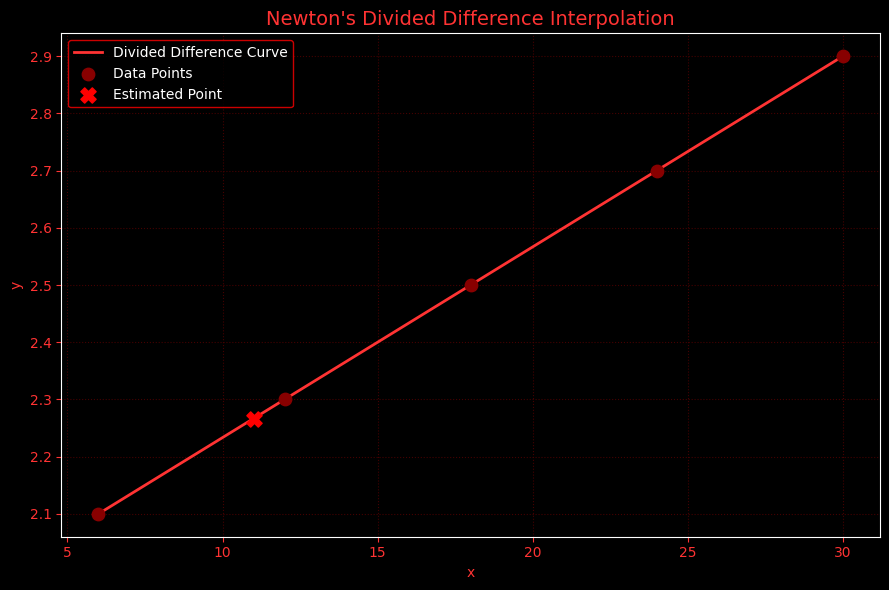

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

x_target = float(input("Enter the interpolation point (x) to estimate y: "))

n = len(x_pts)

# 2. Construct Divided Difference Table
div_table = np.zeros((n, n))
div_table[:, 0] = y_pts

for j in range(1, n):
    for i in range(n - j):
        div_table[i, j] = (div_table[i + 1, j - 1] - div_table[i, j - 1]) / (x_pts[i + j] - x_pts[i])

# Display Table
print("\n--- Divided Difference Table ---")
header = f"{'x':<10}{f'[x_i]':<12}" + "".join([f"f[x_i..x_i+{j}]:<15" for j in range(1, n)])
print(header)
print("-" * (10 + 15 * n))
for i in range(n):
    row_str = f"{x_pts[i]:<10.4f}"
    for j in range(n - i):
        row_str += f"{div_table[i, j]:<15.4f}"
    print(row_str)

# 3. Compute Interpolation Value
y_target = div_table[0, 0]
x_term = 1.0

for j in range(1, n):
    x_term *= (x_target - x_pts[j - 1])
    y_target += x_term * div_table[0, j]

print("-" * (10 + 15 * n))
print(f"Interpolated value at x = {x_target:.4f} is y = {y_target:.6f}")

# 4. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate smooth evaluation curve across domain
x_dense = np.linspace(min(x_pts), max(x_pts), 500)
y_dense = []

for x_val in x_dense:
    y_val = div_table[0, 0]
    x_term_dense = 1.0
    for j in range(1, n):
        x_term_dense *= (x_val - x_pts[j - 1])
        y_val += x_term_dense * div_table[0, j]
    y_dense.append(y_val)

ax.plot(x_dense, y_dense, color='#FF3333', linewidth=2, label='Divided Difference Curve')
ax.scatter(x_pts, y_pts, color='#880000', s=80, zorder=4, label='Data Points')
ax.scatter(x_target, y_target, color='#FF0000', s=120, zorder=5, marker='X', label=f'Estimated Point')

ax.set_title("Newton's Divided Difference Interpolation", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

##8.2  Inverse Interpolation

### Algorithm Logic


Standard interpolation finds the value of $y$ corresponding to a given target $x$. Inverse Interpolation flips this process: given a target value $y$, it estimates the corresponding value of $x$.

When the independent data points $x$ are unequally spaced, we apply Lagrange's Inverse Interpolation Method. We treat $y$ as the independent variable and $x$ as the dependent variable. The estimation formula is constructed as:$$x(y) = \sum_{i=0}^{n-1} L_i(y) \cdot x_i$$Where the inverted Lagrange basis coefficients $L_i(y)$ are computed as:$$L_i(y) = \prod_{j \neq i} \frac{y - y_j}{y_i - y_j}$$

Enter x values separated by spaces: 7 14 21 28 35
Enter corresponding y values separated by spaces: 3 6 9 12 15 
Enter the target y value to estimate its corresponding x: 8

--- Inverse Basis Coefficients (L_i) Calculation ---
L_0(y=8.0000) = -0.028807
L_1(y=8.0000) = 0.288066
L_2(y=8.0000) = 0.864198
L_3(y=8.0000) = -0.144033
L_4(y=8.0000) = 0.020576
---------------------------------------------
Estimated value at y = 8.0000 is x = 18.666667


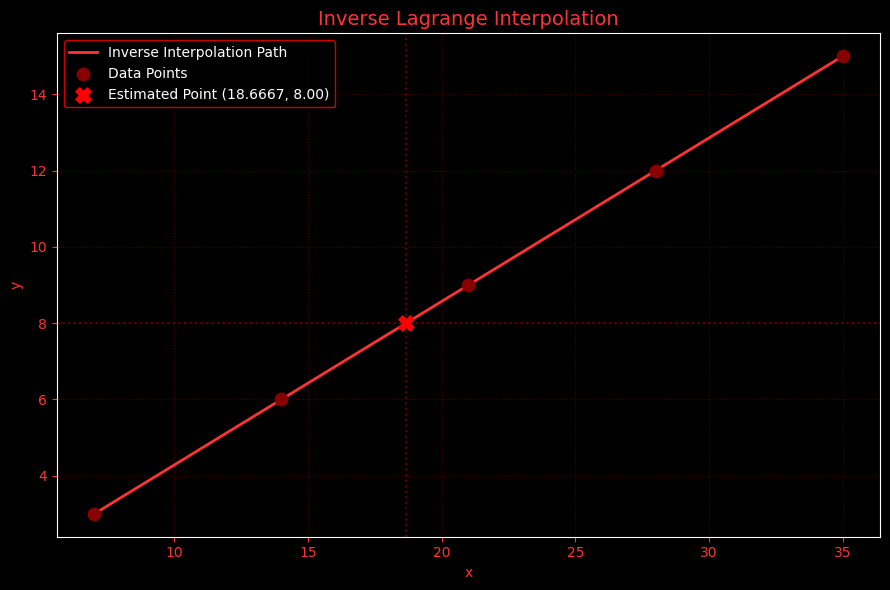

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

y_target = float(input("Enter the target y value to estimate its corresponding x: "))

n = len(x_pts)

# 2. Compute Inverse Lagrange Interpolation
x_target = 0.0

print("\n--- Inverse Basis Coefficients (L_i) Calculation ---")
for i in range(n):
    term = 1.0
    for j in range(n):
        if i != j:
            term *= (y_target - y_pts[j]) / (y_pts[i] - y_pts[j])

    x_target += term * x_pts[i]
    print(f"L_{i}(y={y_target:.4f}) = {term:.6f}")

print("-" * 45)
print(f"Estimated value at y = {y_target:.4f} is x = {x_target:.6f}")

# 3. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate smooth plotting curve by running standard interpolation across a dense grid
y_dense = np.linspace(min(y_pts), max(y_pts), 500)
x_dense = []

for y_val in y_dense:
    x_val = 0.0
    for i in range(n):
        term = 1.0
        for j in range(n):
            if i != j:
                term *= (y_val - y_pts[j]) / (y_pts[i] - y_pts[j])
        x_val += term * x_pts[i]
    x_dense.append(x_val)

# Plot mapping trajectory
ax.plot(x_dense, y_dense, color='#FF3333', linewidth=2, label='Inverse Interpolation Path')
ax.scatter(x_pts, y_pts, color='#880000', s=80, zorder=4, label='Data Points')

# Draw explicit tracking lines showing the mapping from the y-axis down to the calculated x-axis point
ax.axhline(y_target, color='#880000', linestyle=':', alpha=0.7)
ax.axvline(x_target, color='#880000', linestyle=':', alpha=0.7)

# Highlight calculated target coordinate
ax.scatter(x_target, y_target, color='#FF0000', s=120, zorder=5, marker='X', label=f'Estimated Point ({x_target:.4f}, {y_target:.2f})')

ax.set_title("Inverse Lagrange Interpolation", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

#Experiment 9: Statistical Curve Fitting

##9.1 Power Curve Fitting

##Algorithm Logic

Power Curve Fitting fits an exponential relationship between data variables modeled by the nonlinear expression:$$y = a x^b$$

To solve this using linear least-squares regression, we transform the nonlinear model into a linear equation by taking the natural logarithm ($\ln$) of both sides:$$\ln(y) = \ln(a) + b \ln(x)$$

By substituting variables such that $Y = \ln(y)$, $X = \ln(x)$, and $A = \ln(a)$, we get a standard linear equation:$$Y = A + bX$$

We construct and solve the normal system of equations for linear regression:$$n A + b \sum X = \sum Y$$

$$A \sum X + b \sum X^2 = \sum XY$$


Once $A$ and $b$ are determined, we transform $A$ back to scale to find the original coefficient: $a = e^A$.

<>:48: SyntaxWarning: invalid escape sequence '\c'
<>:48: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1380/1697543189.py:48: SyntaxWarning: invalid escape sequence '\c'
  ax.plot(x_dense, y_fitted, color='#FF3333', linewidth=2, label=f'$y = {a:.3f} \cdot x^{{{b:.3f}}}$')


Enter x values separated by spaces: 2 4 6 8 10 
Enter corresponding y values separated by spaces: 1 3 5 7 9 

--- Summary Statistics ---
Calculated intercept coefficient (a): 0.414257
Calculated power exponent factor (b): 1.364015
Resulting Best Fit Power Equation: y = 0.4143 * x^(1.3640)
---------------------------------------------


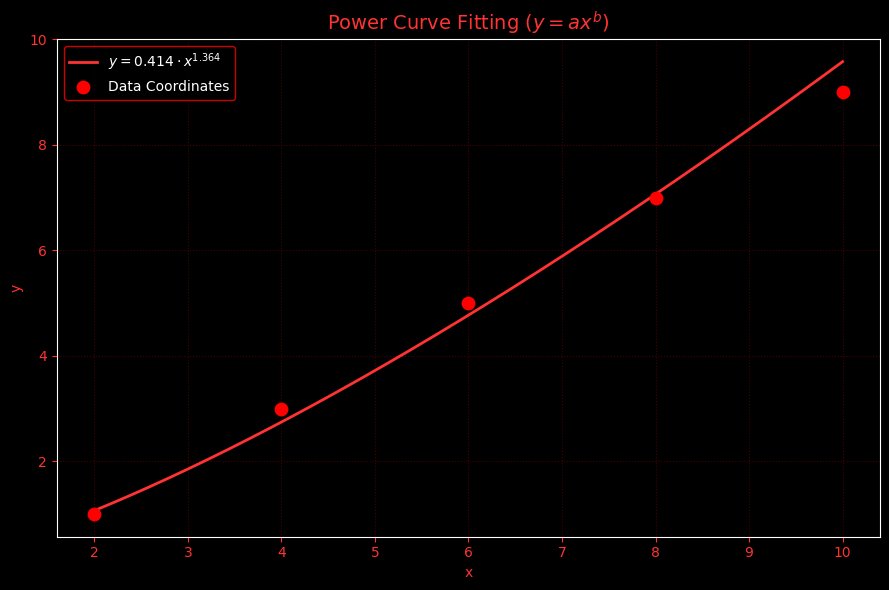

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

n = len(x_pts)

# 2. Linear Transformation Logs
X = np.log(x_pts)
Y = np.log(y_pts)

sum_X = np.sum(X)
sum_Y = np.sum(Y)
sum_X2 = np.sum(X**2)
sum_XY = np.sum(X * Y)

# Solve the linear system using Cramer's rule matrix determinants
denom = n * sum_X2 - sum_X**2
if abs(denom) < 1e-15:
    print("\n[Error]: Matrix determinant calculation collapsed. Cannot fit power trend line.")
else:
    A = (sum_Y * sum_X2 - sum_X * sum_XY) / denom
    b = (n * sum_XY - sum_X * sum_Y) / denom
    a = np.exp(A)  # Convert intercept back to original scale

    print("\n--- Summary Statistics ---")
    print(f"Calculated intercept coefficient (a): {a:.6f}")
    print(f"Calculated power exponent factor (b): {b:.6f}")
    print(f"Resulting Best Fit Power Equation: y = {a:.4f} * x^({b:.4f})")
    print("-" * 45)

    # 3. Visualization Construction
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
    ax.set_facecolor('#000000')

    # Generate continuous dense coordinates for smooth equation rendering
    x_dense = np.linspace(min(x_pts), max(x_pts), 500)
    y_fitted = a * (x_dense ** b)

    # Plot curves and analytical points
    ax.plot(x_dense, y_fitted, color='#FF3333', linewidth=2, label=f'$y = {a:.3f} \cdot x^{{{b:.3f}}}$')
    ax.scatter(x_pts, y_pts, color='#FF0000', s=80, zorder=4, label='Data Coordinates')

    ax.set_title("Power Curve Fitting ($y = ax^b$)", color='#FF3333', fontsize=14)
    ax.set_xlabel("x", color='#FF3333')
    ax.set_ylabel("y", color='#FF3333')
    ax.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax.tick_params(colors='#FF3333')
    ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

    plt.tight_layout()
    plt.show()

##9.2 Exponential Curve Fitting

##Algorithm Logic

Exponential Curve Fitting fits a non-linear relationship between data variables modeled by the following expression:$$y = a e^{bx}$$
To solve this using linear least-squares regression, we transform the non-linear model into a linear format by taking the natural logarithm ($\ln$) of both sides:

$$\ln(y) = \ln(a) + b x$$

By substituting variables such that $Y = \ln(y)$ and $A = \ln(a)$, we get a standard linear straight-line equation:$$Y = A + b x$$

We construct and solve the normal system of equations for linear regression:$$n A + b \sum x = \sum Y$$

$$ A \sum x + b \sum x^2 = \sum (x Y)$$Once $A$ and $b$ are determined, we transform $A$ back to its original scale to find the coefficient: $a = e^A$.

<>:47: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1380/2844365337.py:47: SyntaxWarning: invalid escape sequence '\c'
  ax.plot(x_dense, y_fitted, color='#FF3333', linewidth=2, label=f'$y = {a:.3f} \cdot e^{{{b:.3f}x}}$')


Enter x values separated by spaces: 3 6 9 12 15
Enter corresponding y values separated by spaces: 1 3 5 7 9 

--- Summary Statistics ---
Calculated intercept coefficient (a): 0.816860
Calculated growth/decay factor (b): 0.174725
Resulting Best Fit Exponential Equation: y = 0.8169 * e^(0.1747x)
---------------------------------------------


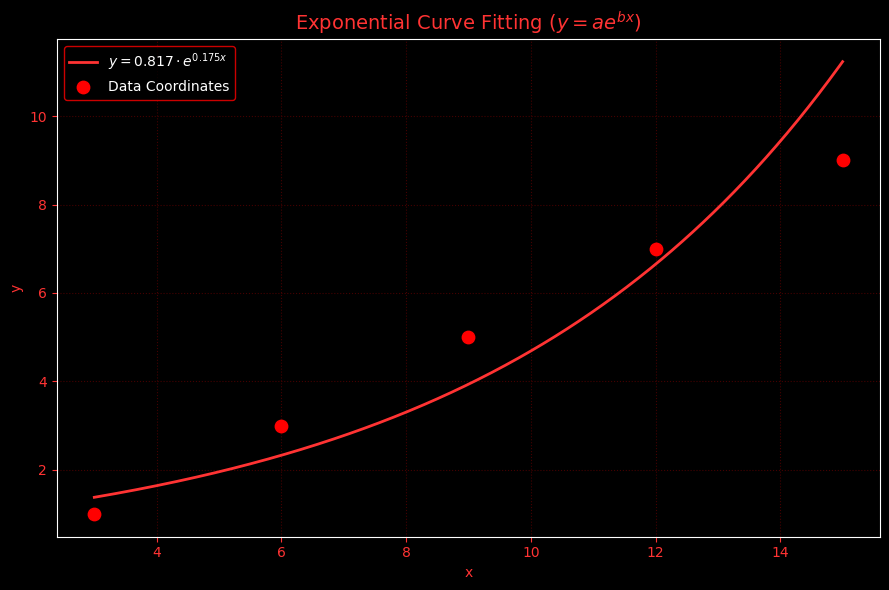

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

n = len(x_pts)

# 2. Linear Transformation
Y = np.log(y_pts)

sum_x = np.sum(x_pts)
sum_Y = np.sum(Y)
sum_x2 = np.sum(x_pts**2)
sum_xY = np.sum(x_pts * Y)

# Solve using Cramer's Rule determinants
denom = n * sum_x2 - sum_x**2
if abs(denom) < 1e-15:
    print("\n[Error]: Matrix determinant calculation collapsed. Cannot fit exponential trend line.")
else:
    A = (sum_Y * sum_x2 - sum_x * sum_xY) / denom
    b = (n * sum_xY - sum_x * sum_Y) / denom
    a = np.exp(A)  # Convert intercept back to original scale

    print("\n--- Summary Statistics ---")
    print(f"Calculated intercept coefficient (a): {a:.6f}")
    print(f"Calculated growth/decay factor (b): {b:.6f}")
    print(f"Resulting Best Fit Exponential Equation: y = {a:.4f} * e^({b:.4f}x)")
    print("-" * 45)

    # 3. Visualization Construction
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
    ax.set_facecolor('#000000')

    # Generate continuous dense coordinates for smooth equation rendering
    x_dense = np.linspace(min(x_pts), max(x_pts), 500)
    y_fitted = a * np.exp(b * x_dense)

    # Plot curves and analytical points
    ax.plot(x_dense, y_fitted, color='#FF3333', linewidth=2, label=f'$y = {a:.3f} \cdot e^{{{b:.3f}x}}$')
    ax.scatter(x_pts, y_pts, color='#FF0000', s=80, zorder=4, label='Data Coordinates')

    ax.set_title("Exponential Curve Fitting ($y = a e^{bx}$)", color='#FF3333', fontsize=14)
    ax.set_xlabel("x", color='#FF3333')
    ax.set_ylabel("y", color='#FF3333')
    ax.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax.tick_params(colors='#FF3333')
    ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

    plt.tight_layout()
    plt.show()

#Experiment 10: Numerical Differentiation & Basic Integration


##10.1 Numerical Differentiation using Finite Differences

##Algorithm Logic

This experiment implements numerical differentiation for tabular (discrete) datasets where functional forms are unavailable.

It computes the derivative at each data point by matching its location boundary parameters:Forward Difference (applied to the first point, index $i=0$):$$f'(x_0) \approx \frac{y_1 - y_0}{h}$$Central Difference (applied to all interior points, indices $0 < i < n-1$):$$f'(x_i) \approx \frac{y_{i+1} - y_{i-1}}{2h}$$Backward Difference (applied to the final boundary point, index $i=n-1$):$$f'(x_{n-1}) \approx \frac{y_{n-1} - y_{n-2}}{h}$$

Enter equally spaced x values separated by spaces: 5 15 25 35 45
Enter corresponding y values separated by spaces: 2 4 6 8 10

x           y           Approx Derivative (dy/dx)
--------------------------------------------------
5.0000      2.0000      0.200000                 
15.0000     4.0000      0.200000                 
25.0000     6.0000      0.200000                 
35.0000     8.0000      0.200000                 
45.0000     10.0000     0.200000                 


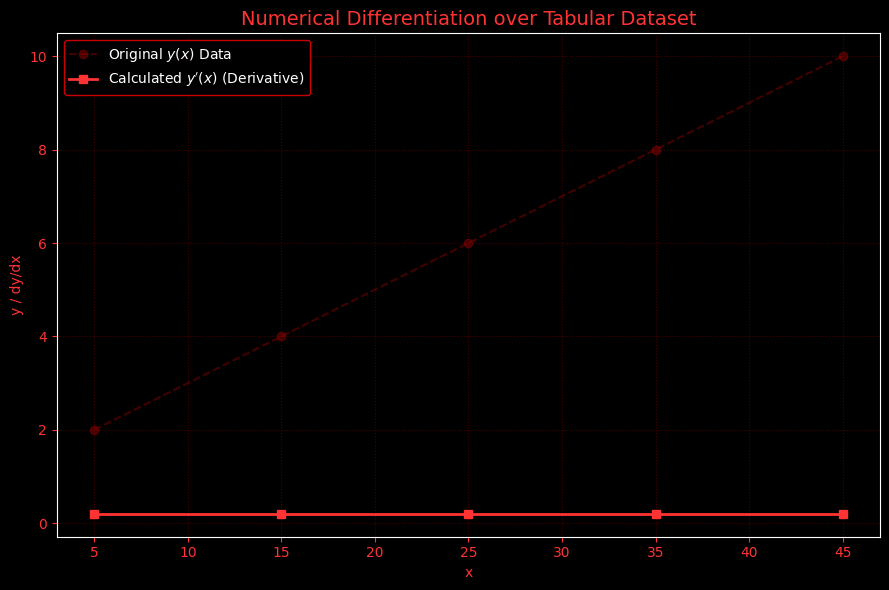

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
x_input = input("Enter equally spaced x values separated by spaces: ")
y_input = input("Enter corresponding y values separated by spaces: ")

x_pts = np.array([float(i) for i in x_input.split()], dtype=float)
y_pts = np.array([float(i) for i in y_input.split()], dtype=float)

n = len(x_pts)
h = x_pts[1] - x_pts[0]

# 2. Compute Derivatives over Dataset Bounds
derivatives = np.zeros(n)

# Initial Point: Forward Difference
derivatives[0] = (y_pts[1] - y_pts[0]) / h

# Interior Points: Central Difference
for i in range(1, n - 1):
    derivatives[i] = (y_pts[i + 1] - y_pts[i - 1]) / (2 * h)

# End Point: Backward Difference
derivatives[-1] = (y_pts[-1] - y_pts[-2]) / h

# Display Tabular Solutions
print(f"\n{'x':<12}{'y':<12}{'Approx Derivative (dy/dx)':<25}")
print("-" * 50)
for i in range(n):
    print(f"{x_pts[i]:<12.4f}{y_pts[i]:<12.4f}{derivatives[i]:<25.6f}")

# 3. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Plot original data trend line
ax.plot(x_pts, y_pts, color='#880000', linestyle='--', marker='o', alpha=0.5, label='Original $y(x)$ Data')

# Plot computed derivative values
ax.plot(x_pts, derivatives, color='#FF3333', linewidth=2, marker='s', label="Calculated $y'(x)$ (Derivative)")

ax.set_title("Numerical Differentiation over Tabular Dataset", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y / dy/dx", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

##10.2 Trapezoidal Rule for Numerical Integration


##Algorithm Logic

The Trapezoidal Rule approximates the definite integral of a function over an interval $[a, b]$ by dividing the total area under the curve into $n$ discrete trapezoids.The width of each subinterval (step size) is defined as:$$h = \frac{b - a}{n}$$The area under the curve is then calculated using the boundary values and intermediate coordinates:$$\int_{a}^{b} f(x) \, dx \approx \frac{h}{2} \left[ y_0 + 2(y_1 + y_2 + \dots + y_{n-1}) + y_n \right]$$

Enter the function f(x) to integrate: x*2-6
Enter lower limit of integration (a): -4
Enter upper limit of integration (b): 9
Enter number of subintervals (n): 5
--------------------------------------------------
Calculated Step Size (h): 2.600000
Approximate Integral Value: -13.000000
--------------------------------------------------


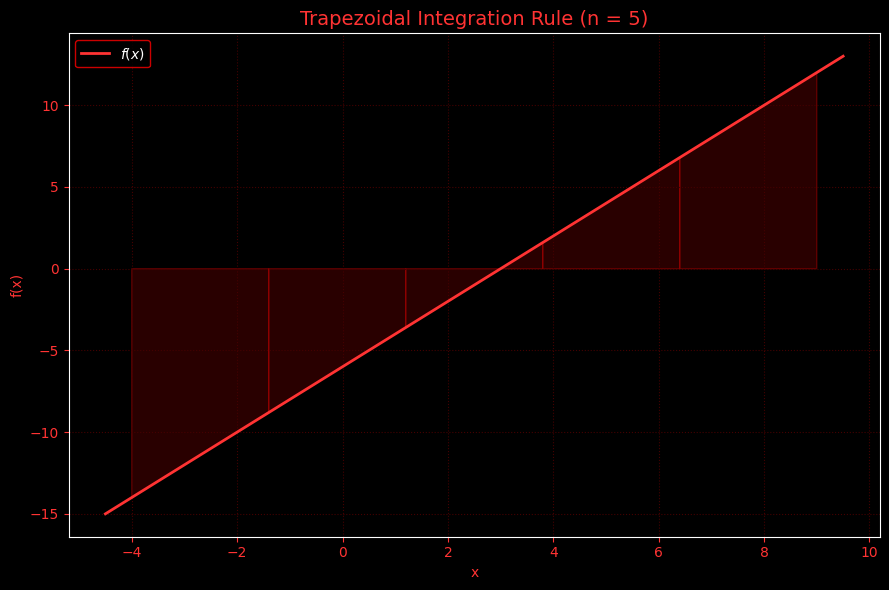

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x) to integrate: ")
f = lambda x: eval(func_str)

a = float(input("Enter lower limit of integration (a): "))
b = float(input("Enter upper limit of integration (b): "))
n = int(input("Enter number of subintervals (n): "))

# 2. Trapezoidal Integration Calculation
h = (b - a) / n
x_vals = np.linspace(a, b, n + 1)
y_vals = f(x_vals)

# Summing the components according to the formula
integral = y_vals[0] + y_vals[-1]
for i in range(1, n):
    integral += 2 * y_vals[i]
integral = (h / 2.0) * integral

print("-" * 50)
print(f"Calculated Step Size (h): {h:.6f}")
print(f"Approximate Integral Value: {integral:.6f}")
print("-" * 50)

# 3. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Generate a dense grid for plotting the true curve smoothly
x_dense = np.linspace(a - 0.5, b + 0.5, 500)
ax.plot(x_dense, f(x_dense), color='#FF3333', linewidth=2, label='$f(x)$')

# Visually draw each trapezoid area under the curve
for i in range(n):
    xs = [x_vals[i], x_vals[i], x_vals[i+1], x_vals[i+1]]
    ys = [0, y_vals[i], y_vals[i+1], 0]
    ax.fill(xs, ys, color='#880000', edgecolor='#FF0000', alpha=0.3, linewidth=1)

ax.set_title(f"Trapezoidal Integration Rule (n = {n})", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("f(x)", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

# Experiment 11: Advanced Numerical Integration

##11.1 Simpson’s 1/3 Rule

##Algorithm Logic

Simpson’s 1/3 Rule provides higher accuracy than the Trapezoidal rule by approximating the curve using a series of parabolic arcs instead of straight lines.

Because each parabola requires 3 points to define, the total number of subintervals ($n$) must be even.The width of each subinterval is defined as:$$h = \frac{b - a}{n}$$The area under the curve is calculated by grouping coefficients based on whether their location indices are odd or even:$$\int_{a}^{b} f(x) \, dx \approx \frac{h}{3} \left[ y_0 + 4(y_1 + y_3 + \dots + y_{n-1}) + 2(y_2 + y_4 + \dots + y_{n-2}) + y_n \right]$$

Enter the function f(x) to integrate: 3*x-5
Enter lower limit of integration (a): 2
Enter upper limit of integration (b): 4
Enter number of subintervals (n - MUST BE EVEN): 8
--------------------------------------------------
Calculated Step Size (h): 0.250000
Approximate Integral Value: 8.000000
--------------------------------------------------


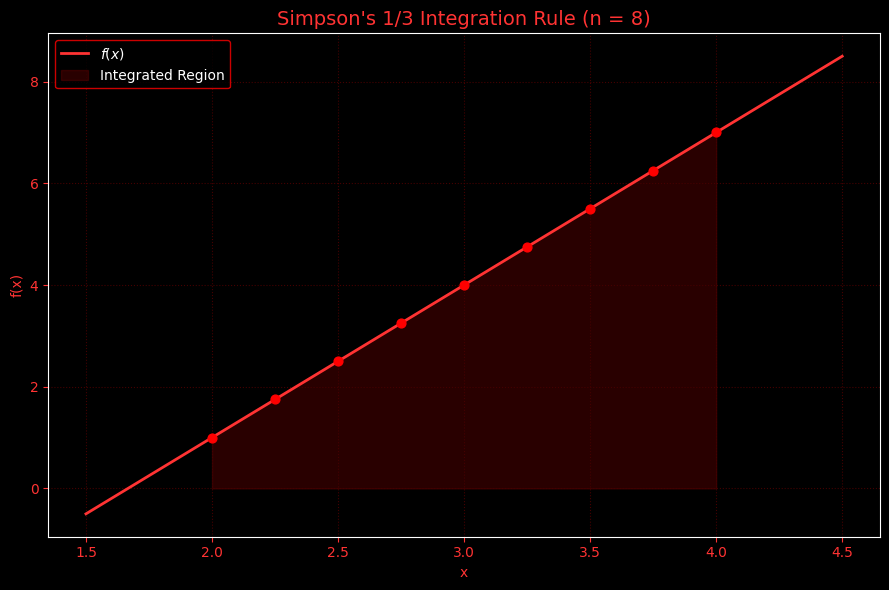

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x) to integrate: ")
f = lambda x: eval(func_str)

a = float(input("Enter lower limit of integration (a): "))
b = float(input("Enter upper limit of integration (b): "))
n = int(input("Enter number of subintervals (n - MUST BE EVEN): "))

if n % 2 != 0:
    print("\n[Error]: Simpson's 1/3 Rule requires an EVEN number of subintervals.")
else:
    # 2. Simpson's 1/3 Core Calculation
    h = (b - a) / n
    x_vals = np.linspace(a, b, n + 1)
    y_vals = f(x_vals)

    # Initialize sum with boundary points
    integral = y_vals[0] + y_vals[-1]

    # Process internal points with appropriate alternating scaling weights
    for i in range(1, n):
        if i % 2 != 0:
            integral += 4 * y_vals[i]   # Odd index multiplier
        else:
            integral += 2 * y_vals[i]   # Even index multiplier

    integral = (h / 3.0) * integral

    print("-" * 50)
    print(f"Calculated Step Size (h): {h:.6f}")
    print(f"Approximate Integral Value: {integral:.6f}")
    print("-" * 50)

    # 3. Visualization Construction
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
    ax.set_facecolor('#000000')

    x_dense = np.linspace(a - 0.5, b + 0.5, 500)
    ax.plot(x_dense, f(x_dense), color='#FF3333', linewidth=2, label='$f(x)$')

    # Shade integration bounds domain uniformly to showcase total evaluated region
    ax.fill_between(x_vals, 0, y_vals, color='#880000', alpha=0.3, label='Integrated Region')
    ax.scatter(x_vals, y_vals, color='#FF0000', s=40, zorder=4)

    ax.set_title(f"Simpson's 1/3 Integration Rule (n = {n})", color='#FF3333', fontsize=14)
    ax.set_xlabel("x", color='#FF3333')
    ax.set_ylabel("f(x)", color='#FF3333')
    ax.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax.tick_params(colors='#FF3333')
    ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

    plt.tight_layout()
    plt.show()

##11.2 Simpson’s 3/8 Rule

##Algorithm Logic

Simpson’s 3/8 Rule fits a cubic polynomial across sets of four points. Because of this cubic grouping structure, the total number of subintervals ($n$) must be a multiple of 3.The width of each subinterval is defined as:$$h = \frac{b - a}{n}$$The area under the curve is calculated using the following weighted summation formula:

$$\int_{a}^{b} f(x) \, dx \approx \frac{3h}{8} \left[ y_0 + 3(y_1 + y_2 + y_4 + y_5 + \dots) + 2(y_3 + y_6 + y_9 + \dots) + y_n \right]$$


In this formula:

Boundaries $y_0$ and $y_n$ are scaled by $1$.Positions that are multiples of 3 ($y_3, y_6, \dots$) are scaled by $2$.All other intermediate positions are scaled by $3$.

Enter the function f(x) to integrate: x*3
Enter lower limit of integration (a): 2
Enter upper limit of integration (b): 8
Enter number of subintervals (n - MUST BE A MULTIPLE OF 3): 9
--------------------------------------------------
Calculated Step Size (h): 0.666667
Approximate Integral Value: 90.000000
--------------------------------------------------


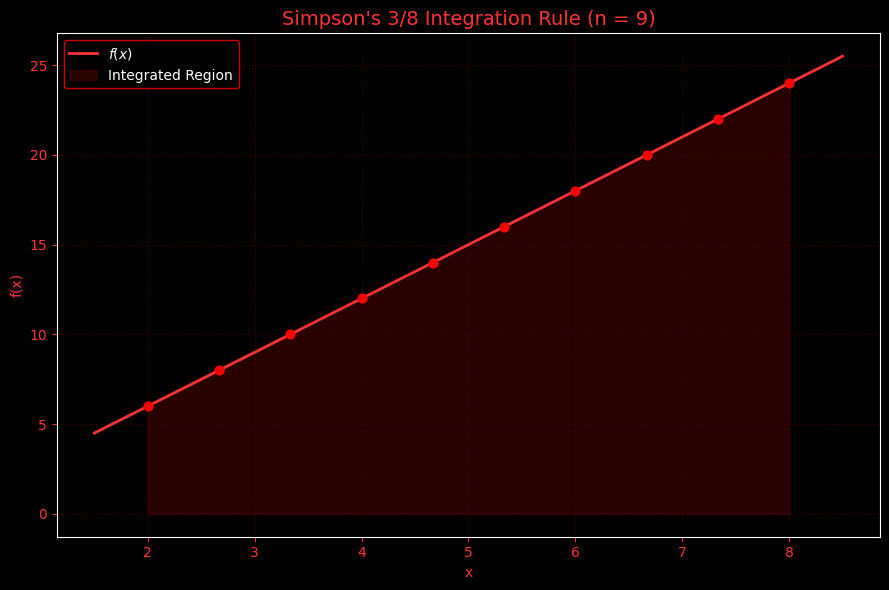

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
func_str = input("Enter the function f(x) to integrate: ")
f = lambda x: eval(func_str)

a = float(input("Enter lower limit of integration (a): "))
b = float(input("Enter upper limit of integration (b): "))
n = int(input("Enter number of subintervals (n - MUST BE A MULTIPLE OF 3): "))

if n % 3 != 0:
    print("\n[Error]: Simpson's 3/8 Rule requires subintervals to be a multiple of 3.")
else:
    # 2. Simpson's 3/8 Core Calculation
    h = (b - a) / n
    x_vals = np.linspace(a, b, n + 1)
    y_vals = f(x_vals)

    # Initialize sum with boundary points
    integral = y_vals[0] + y_vals[-1]

    # Process internal points with matching 3/8 structural weights
    for i in range(1, n):
        if i % 3 == 0:
            integral += 2 * y_vals[i]   # Multiples of 3 weight factor
        else:
            integral += 3 * y_vals[i]   # Standard intermediate weight factor

    integral = (3 * h / 8.0) * integral

    print("-" * 50)
    print(f"Calculated Step Size (h): {h:.6f}")
    print(f"Approximate Integral Value: {integral:.6f}")
    print("-" * 50)

    # 3. Visualization Construction
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
    ax.set_facecolor('#000000')

    x_dense = np.linspace(a - 0.5, b + 0.5, 500)
    ax.plot(x_dense, f(x_dense), color='#FF3333', linewidth=2, label='$f(x)$')

    # Shade integration bounds domain uniformly to showcase total evaluated region
    ax.fill_between(x_vals, 0, y_vals, color='#880000', alpha=0.3, label='Integrated Region')
    ax.scatter(x_vals, y_vals, color='#FF0000', s=40, zorder=4)

    ax.set_title(f"Simpson's 3/8 Integration Rule (n = {n})", color='#FF3333', fontsize=14)
    ax.set_xlabel("x", color='#FF3333')
    ax.set_ylabel("f(x)", color='#FF3333')
    ax.grid(color='#440000', linestyle=':', linewidth=0.8)
    ax.tick_params(colors='#FF3333')
    ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

    plt.tight_layout()
    plt.show()

#Experiment 12: Numerical Solutions to Ordinary Differential Equations (ODEs)

##12.1 Modified Euler’s Method

##Algorithm Logic


Modified Euler's Method solves ordinary differential equations (ODEs) of the form $\frac{dy}{dx} = f(x, y)$ with an initial condition $y(x_0) = y_0$.


It improves upon the standard Euler method by using a predictor-corrector approach.Predictor Step: It estimates an initial value for the next point ($\tilde{y}_{n+1}$) using a standard forward Euler step:$$\tilde{y}_{n+1} = y_n + h \cdot f(x_n, y_n)$$

Corrector Step: It refines this prediction by averaging the slopes computed at the current point and the predicted next point:$$y_{n+1} = y_n + \frac{h}{2} \left[ f(x_n, y_n) + f(x_{n+1}, \tilde{y}_{n+1}) \right]$$

Enter the differential equation derivative function f(x, y): x+y
Enter initial condition x0: 5
Enter initial condition y0: 8
Enter evaluation target endpoint x_end: 4
Enter calculation step size h: 1.2

Step    x_n         Predicted y    Corrected y_n  
--------------------------------------------------


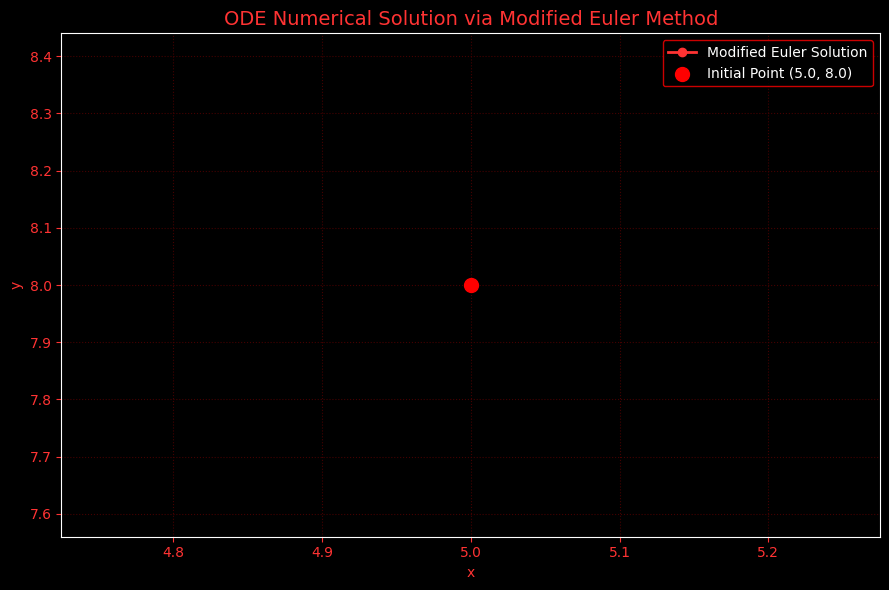

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
dydx_str = input("Enter the differential equation derivative function f(x, y): ")
f = lambda x, y: eval(dydx_str)

x0 = float(input("Enter initial condition x0: "))
y0 = float(input("Enter initial condition y0: "))
x_end = float(input("Enter evaluation target endpoint x_end: "))
h = float(input("Enter calculation step size h: "))

# 2. Setup Step Vectors
steps = int(np.ceil((x_end - x0) / h))
x_vals = np.zeros(steps + 1)
y_vals = np.zeros(steps + 1)

x_vals[0] = x0
y_vals[0] = y0

print(f"\n{'Step':<8}{'x_n':<12}{'Predicted y':<15}{'Corrected y_n':<15}")
print("-" * 50)

# Run Predictor-Corrector Loop Iterations
for n in range(steps):
    x_curr = x_vals[n]
    y_curr = y_vals[n]

    # Predictor step (Standard Euler)
    slope_curr = f(x_curr, y_curr)
    y_predict = y_curr + h * slope_curr

    # Next x coordinate boundary positioning
    x_next = x_curr + h
    if x_next > x_end:
        h = x_end - x_curr
        x_next = x_end
        y_predict = y_curr + h * slope_curr

    # Corrector step (Modified Euler calculation)
    slope_next = f(x_next, y_predict)
    y_correct = y_curr + (h / 2.0) * (slope_curr + slope_next)

    # Save values
    x_vals[n+1] = x_next
    y_vals[n+1] = y_correct

    print(f"{n+1:<8}{x_next:<12.4f}{y_predict:<15.6f}{y_correct:<15.6f}")

# 3. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Plot approximate solution path layout
ax.plot(x_vals, y_vals, color='#FF3333', linewidth=2, marker='o', label="Modified Euler Solution")
ax.scatter(x0, y0, color='#FF0000', s=100, zorder=5, label=f'Initial Point ({x0}, {y0})')

ax.set_title("ODE Numerical Solution via Modified Euler Method", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

##12.2 Runge–Kutta Method (RK4)

##Algorithm Logic


The Fourth-Order Runge–Kutta method (RK4) is one of the most widely used numerical techniques for solving ODEs because of its exceptionally high tracking accuracy (fourth-order local truncation accuracy, $O(h^4)$).


Instead of evaluating a single slope, RK4 takes four weighted slope estimates across the
step interval:

$k_1$: Slope at the beginning of the step interval.

$k_2$: Estimated slope at the interval midpoint using $k_1$.

$k_3$: Refined slope at the interval midpoint using $k_2$.

$k_4$: Slope at the endpoint of the interval using $k_3$.

The state update formula transitions forward via a weighted average of these components:

$$y_{n+1} = y_n + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

Enter the differential equation derivative function f(x, y): x+y
Enter initial condition x0: 2
Enter initial condition y0: 5
Enter evaluation target endpoint x_end: 9
Enter calculation step size h: 1.8

Step  x_n       k1          k2          k3          k4          y_n         
---------------------------------------------------------------------------
1     3.800     12.60000    25.56000    37.22400    82.84320    41.83520    
2     5.600     82.14336    157.69238   225.68651   491.61907   265.25523   
3     7.400     487.53942   927.94490   1324.30984  2874.53713  1576.35291  
4     9.000     2534.00465  4562.48837  6185.27535  12433.00520 7653.44245  


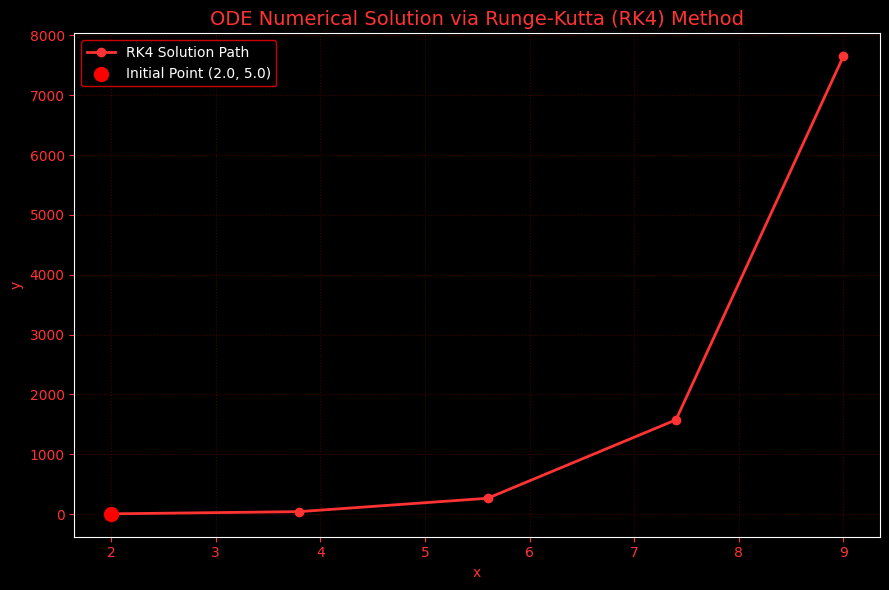

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
dydx_str = input("Enter the differential equation derivative function f(x, y): ")
f = lambda x, y: eval(dydx_str)

x0 = float(input("Enter initial condition x0: "))
y0 = float(input("Enter initial condition y0: "))
x_end = float(input("Enter evaluation target endpoint x_end: "))
h = float(input("Enter calculation step size h: "))

# 2. Setup Step Vectors
steps = int(np.ceil((x_end - x0) / h))
x_vals = np.zeros(steps + 1)
y_vals = np.zeros(steps + 1)

x_vals[0] = x0
y_vals[0] = y0

print(f"\n{'Step':<6}{'x_n':<10}{'k1':<12}{'k2':<12}{'k3':<12}{'k4':<12}{'y_n':<12}")
print("-" * 75)

# RK4 Execution Loop
for n in range(steps):
    x_curr = x_vals[n]
    y_curr = y_vals[n]

    # Adjust step size if it exceeds the endpoint
    if x_curr + h > x_end:
        h = x_end - x_curr

    # Compute the 4 RK Runge steps
    k1 = h * f(x_curr, y_curr)
    k2 = h * f(x_curr + h/2.0, y_curr + k1/2.0)
    k3 = h * f(x_curr + h/2.0, y_curr + k2/2.0)
    k4 = h * f(x_curr + h, y_curr + k3)

    # Update state profile vectors
    y_next = y_curr + (k1 + 2*k2 + 2*k3 + k4) / 6.0
    x_next = x_curr + h

    x_vals[n+1] = x_next
    y_vals[n+1] = y_next

    print(f"{n+1:<6}{x_next:<10.3f}{k1:<12.5f}{k2:<12.5f}{k3:<12.5f}{k4:<12.5f}{y_next:<12.5f}")

# 3. Visualization Construction
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Plot approximate solution path layout
ax.plot(x_vals, y_vals, color='#FF3333', linewidth=2, marker='o', label="RK4 Solution Path")
ax.scatter(x0, y0, color='#FF0000', s=100, zorder=5, label=f'Initial Point ({x0}, {y0})')

ax.set_title("ODE Numerical Solution via Runge-Kutta (RK4) Method", color='#FF3333', fontsize=14)
ax.set_xlabel("x", color='#FF3333')
ax.set_ylabel("y", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

#Experiment 13: Partial Differential Equations – Parabolic

##13.1. Finite Difference Method for Heat Equation





##Algorithmic Logic

The 1D Heat Equation is a classic parabolic partial differential equation describing how temperature diffuses through a material over time:$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

To solve this computationally, we apply the FTCS (Forward-Time Central-Space) explicit finite difference scheme:

Forward Difference in Time ($O(\Delta t)$): $\frac{\partial u}{\partial t} \approx \frac{u_i^{n+1} - u_i^n}{\Delta t}$Central Difference in Space ($O(\Delta x^2)$): $\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$


Substituting these back into the heat equation yields the explicit update formula for the next time step ($n+1$):$$u_i^{n+1} = u_i^n + r \left( u_{i+1}^n - 2u_i^n + u_{i-1}^n \right)$$Where $r$ is the mesh Fourier number:$$r = \alpha \frac{\Delta t}{\Delta x^2}$$Numerical Stability Guardrail: For the explicit FTCS scheme to be stable and avoid wild divergence, the parameters must satisfy $r \le 0.5$.

Enter length of the rod (L): 5
Enter total simulation time (T_max): 45
Enter thermal diffusivity constant (alpha): 6.2
Enter number of space intervals (nx): 7
Enter number of time steps (nt): 14

Calculated dx: 0.7143, dt: 3.2143
Mesh Stability Factor r = 39.0600
[Warning]: r (39.0600) > 0.5. The solution will likely diverge numerically due to FTCS instability constraints.
Do you still wish to run the simulation? (yes/no): yes
Enter uniform initial temperature of the rod: 265
Enter fixed boundary temperature at left end (x=0): 123
Enter fixed boundary temperature at right end (x=L): 78


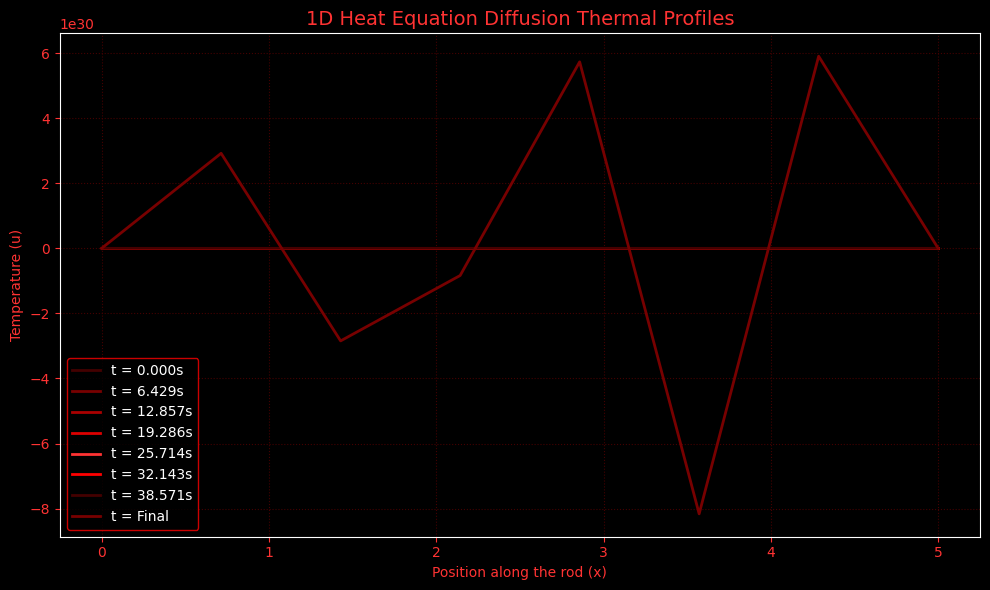

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
L = float(input("Enter length of the rod (L): "))
T_max = float(input("Enter total simulation time (T_max): "))
alpha = float(input("Enter thermal diffusivity constant (alpha): "))

nx = int(input("Enter number of space intervals (nx): "))
nt = int(input("Enter number of time steps (nt): "))

# 2. Derive Mesh Increments
dx = L / nx
dt = T_max / nt
r = alpha * dt / (dx ** 2)

print(f"\nCalculated dx: {dx:.4f}, dt: {dt:.4f}")
print(f"Mesh Stability Factor r = {r:.4f}")

if r > 0.5:
    print(f"[Warning]: r ({r:.4f}) > 0.5. The solution will likely diverge numerically due to FTCS instability constraints.")
    proceed = input("Do you still wish to run the simulation? (yes/no): ").strip().lower()
    if proceed != 'yes':
        raise SystemExit("Simulation terminated to prevent instability breakdown.")

# 3. Boundary & Initial Conditions Input System
u0 = float(input("Enter uniform initial temperature of the rod: "))
u_left = float(input("Enter fixed boundary temperature at left end (x=0): "))
u_right = float(input("Enter fixed boundary temperature at right end (x=L): "))

# Initialize grid array data structures (Rows = Time steps, Columns = Space intervals)
u = np.full((nt + 1, nx + 1), u0)

# Apply Boundary Constraints
u[:, 0] = u_left
u[:, -1] = u_right

# 4. Explicit Finite Difference Engine Loop Execution
for n in range(nt):
    for i in range(1, nx):
        u[n+1, i] = u[n, i] + r * (u[n, i+1] - 2 * u[n, i] + u[n, i-1])

# 5. Visualization Construction (Evolution Line Matrix Layout)
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#000000')
ax.set_facecolor('#000000')

x_grid = np.linspace(0, L, nx + 1)

# Pick distinct time slice snaps to overlay distribution paths smoothly
plot_intervals = max(1, nt // 5)
shades_of_red = ['#440000', '#770000', '#AA0000', '#DD0000', '#FF3333', '#FF0000']

color_idx = 0
for n in range(0, nt + 1, plot_intervals):
    label_str = f"t = {n * dt:.3f}s" if n < nt else "t = Final"
    color_code = shades_of_red[color_idx % len(shades_of_red)]
    ax.plot(x_grid, u[n, :], color=color_code, linewidth=2, label=label_str)
    color_idx += 1

# Make sure final line stands out prominently
if nt % plot_intervals != 0:
    ax.plot(x_grid, u[-1, :], color='#FF0000', linewidth=2.5, linestyle='--', label="Final Profile")

ax.set_title("1D Heat Equation Diffusion Thermal Profiles", color='#FF3333', fontsize=14)
ax.set_xlabel("Position along the rod (x)", color='#FF3333')
ax.set_ylabel("Temperature (u)", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

#Experiment 14: Partial Differential Equations - Hyperbolic

##14.1. Finite Difference Method for Wave Equation

#Algorithm Logic


The 1D Wave Equation is a classic hyperbolic partial differential equation describing the propagation of waves (such as a vibrating string):

$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$

To solve this computationally, we approximate the second-order derivatives using central differences in both time and space:

Time Derivative ($O(\Delta t^2)$):

 $\frac{\partial^2 u}{\partial t^2} \approx \frac{u_i^{n+1} - 2u_i^n + u_i^{n-1}}{\Delta t^2}$

 Space Derivative ($O(\Delta x^2)$):

  $\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$
  
  Substituting these approximations back into the wave equation gives the explicit recurrence update formula for the next time layer ($n+1$):$$u_i^{n+1} = 2(1 - \lambda^2)u_i^n + \lambda^2(u_{i+1}^n + u_{i-1}^n) - u_i^{n-1}$$Where $\lambda$ represents the Courant-Friedrichs-Lewy (CFL) parameter:


  
  $$\lambda = c \frac{\Delta t}{\Delta x}$$
  
  
  Numerical Stability Guardrail (CFL Condition): For the wave propagation calculation to remain stable, the parameters must satisfy $\lambda \le 1.0$. If $\lambda > 1.0$, numerical errors amplify explosively.
  
  
  Handling the First Time Step ($n=0$)The standard update formula requires a previous step state $u_i^{n-1}$.
  
  For the very first step update layer ($n=1$), this value does not exist.
  
  We resolve this by incorporating the initial velocity boundary condition $\frac{\partial u}{\partial t} = g(x) = 0$ via a ghost-cell boundary approach, yielding a specialized first-step initialization formula:$$u_i^1 = (1 - \lambda^2)u_i^0 + \frac{\lambda^2}{2}(u_{i+1}^0 + u_{i-1}^0)$$

Enter length of the string (L): 5
Enter total simulation tracking time (T_max): 4
Enter wave propagation speed constant (c): 3.8
Enter number of space intervals (nx): 5
Enter number of time steps (nt): 6

Calculated dx: 1.0000, dt: 0.6667
Courant Factor (lambda) = 2.5333
[Warning]: lambda (2.5333) > 1.0. This configuration violates the CFL condition and will diverge.
Do you still wish to run the simulation? (yes/no): yes


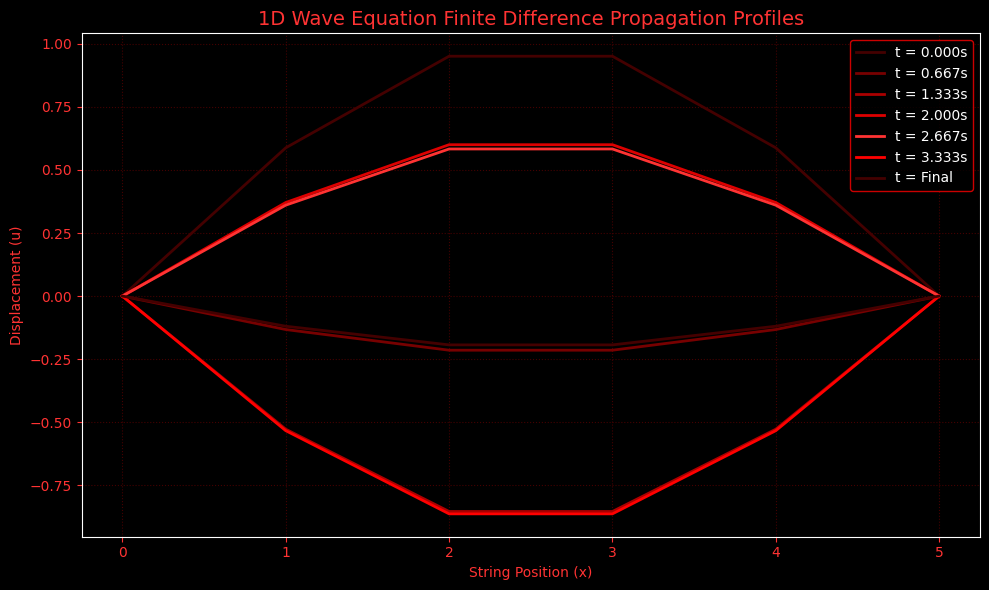

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Inputs
L = float(input("Enter length of the string (L): "))
T_max = float(input("Enter total simulation tracking time (T_max): "))
c = float(input("Enter wave propagation speed constant (c): "))

nx = int(input("Enter number of space intervals (nx): "))
nt = int(input("Enter number of time steps (nt): "))

# 2. Derive Grid Increments
dx = L / nx
dt = T_max / nt
wave_lambda = c * dt / dx

print(f"\nCalculated dx: {dx:.4f}, dt: {dt:.4f}")
print(f"Courant Factor (lambda) = {wave_lambda:.4f}")

if wave_lambda > 1.0:
    print(f"[Warning]: lambda ({wave_lambda:.4f}) > 1.0. This configuration violates the CFL condition and will diverge.")
    proceed = input("Do you still wish to run the simulation? (yes/no): ").strip().lower()
    if proceed != 'yes':
        raise SystemExit("Simulation terminated to prevent numerical breakdown.")

# 3. Setup Computational Arrays (Rows = Time steps, Columns = Space intervals)
u = np.zeros((nt + 1, nx + 1))
x_grid = np.linspace(0, L, nx + 1)

# Apply Boundary Conditions (Fixed ends of the string)
# u(0, t) = 0 and u(L, t) = 0 are maintained by leaving the boundaries as zero

# Apply Initial Profile Shape Condition: a plucked string modeled by a sine wave configuration
# u(x, 0) = sin(pi * x / L)
u[0, :] = np.sin(np.pi * x_grid / L)

# 4. specialized Step 1 Initialization Update (Using g(x) = 0 boundary simplification)
for i in range(1, nx):
    u[1, i] = (1 - wave_lambda**2) * u[0, i] + (wave_lambda**2 / 2.0) * (u[0, i+1] + u[0, i-1])

# 5. Main Finite Difference Loop Engine for Subsequent Time Layers
for n in range(1, nt):
    for i in range(1, nx):
        u[n+1, i] = 2 * (1 - wave_lambda**2) * u[n, i] + \
                    (wave_lambda**2) * (u[n, i+1] + u[n, i-1]) - u[n-1, i]

# 6. Visualization Construction (Time Wave Snapshot Overlay)
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#000000')
ax.set_facecolor('#000000')

# Extract key time snap slices to cleanly observe the standing wave oscillations
plot_intervals = max(1, nt // 5)
shades_of_red = ['#440000', '#770000', '#AA0000', '#DD0000', '#FF3333', '#FF0000']

color_idx = 0
for n in range(0, nt + 1, plot_intervals):
    label_str = f"t = {n * dt:.3f}s" if n < nt else "t = Final"
    color_code = shades_of_red[color_idx % len(shades_of_red)]
    ax.plot(x_grid, u[n, :], color=color_code, linewidth=2, label=label_str)
    color_idx += 1

ax.set_title("1D Wave Equation Finite Difference Propagation Profiles", color='#FF3333', fontsize=14)
ax.set_xlabel("String Position (x)", color='#FF3333')
ax.set_ylabel("Displacement (u)", color='#FF3333')
ax.grid(color='#440000', linestyle=':', linewidth=0.8)
ax.tick_params(colors='#FF3333')
ax.legend(facecolor='#000000', edgecolor='#FF0000', loc='best')

plt.tight_layout()
plt.show()

#Experiment 15: Partial Differential Equations – Elliptic

##17.1. Finite Difference Method for Laplace Equation

##Algorithm Logic

The 2D Laplace Equation is an elliptic partial differential equation that describes steady-state behaviors, such as static temperature configurations or electrostatic potential fields, where time changes are no longer factors:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

To solve this equation across a grid, we approximate the second-order partial derivatives using central differences in both spatial directions:

Space $x$ Derivative ($O(\Delta x^2)$):




$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta x^2}$$



 Space $y$ Derivative ($O(\Delta y^2)$): $\frac{\partial^2 u}{\partial y^2} \approx \frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{\Delta y^2}$


 Assuming a uniform mesh grid step size ($\Delta x = \Delta y = h$), we substitute these approximations into the Laplace equation. This simplifies to the standard Four-Point Liebmann Stencil:$$u_{i,j} = \frac{1}{4} \left( u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} \right)$$This means the value at any interior point is exactly the arithmetic mean of its four closest neighbors.

  Because everything is coupled, the code executes an iterative relaxation engine (using the Jacobi or Gauss-Seidel approach) until the absolute difference between successive sweeps falls below a specified convergence tolerance.

Enter number of grid intervals along X-axis (nx): 2
Enter number of grid intervals along Y-axis (ny): 5
Enter maximum relaxation iterations allowed: 15
Enter convergence error tolerance (e.g., 1e-4): 1e-6

--- Configure Dirichlet Boundary Potentials ---
Enter constant temperature/potential at TOP boundary: 234
Enter constant temperature/potential at BOTTOM boundary: 120
Enter constant temperature/potential at LEFT boundary: 14
Enter constant temperature/potential at RIGHT boundary: 65

Running iterative relaxation solver...
--> Solution successfully converged at iteration count: 12


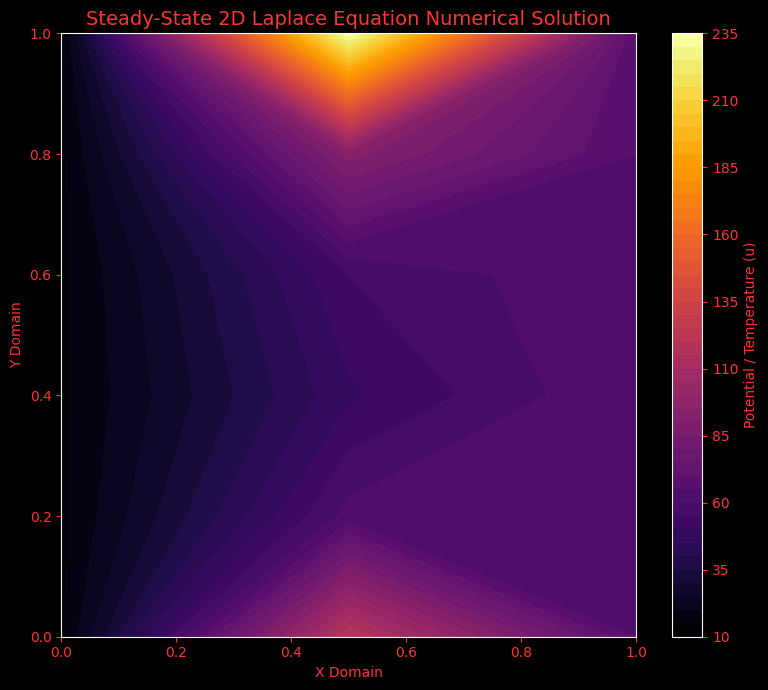

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# 1. User Grid Structure Inputs
nx = int(input("Enter number of grid intervals along X-axis (nx): "))
ny = int(input("Enter number of grid intervals along Y-axis (ny): "))

max_iter = int(input("Enter maximum relaxation iterations allowed: "))
tol = float(input("Enter convergence error tolerance (e.g., 1e-4): "))

# Initialize 2D system grid with zeros
u = np.zeros((ny + 1, nx + 1))

# 2. Boundary Condition Assignment
print("\n--- Configure Dirichlet Boundary Potentials ---")
u[-1, :] = float(input("Enter constant temperature/potential at TOP boundary: "))
u[0, :] = float(input("Enter constant temperature/potential at BOTTOM boundary: "))
u[:, 0] = float(input("Enter constant temperature/potential at LEFT boundary: "))
u[:, -1] = float(input("Enter constant temperature/potential at RIGHT boundary: "))

# 3. Iterative Relaxation Solver Engine (Gauss-Seidel approach)
converged = False
print("\nRunning iterative relaxation solver...")

for iteration in range(max_iter):
    u_old = u.copy()
    max_diff = 0.0

    # Sweep across all interior mesh coordinates exclusively
    for j in range(1, ny):
        for i in range(1, nx):
            # Apply the 4-Point Liebmann Stencil
            u[j, i] = 0.25 * (u[j, i+1] + u[j, i-1] + u[j+1, i] + u[j-1, i])

            # Track maximum localized absolute refinement error
            diff = abs(u[j, i] - u_old[j, i])
            if diff > max_diff:
                max_diff = diff

    # Convergence verification check
    if max_diff < tol:
        print(f"--> Solution successfully converged at iteration count: {iteration + 1}")
        converged = True
        break

if not converged:
    print(f"--> [Warning]: Reached maximum limit of {max_iter} iterations without full convergence.")

# 4. Visualization Construction (Steady State Heatmap Distribution)
fig, ax = plt.subplots(figsize=(8, 7), facecolor='#000000')

# Generate standard dimensional mesh coordinates
X, Y = np.meshgrid(np.linspace(0, 1, nx + 1), np.linspace(0, 1, ny + 1))

# Render continuous field distribution intensities via color filled contour mapping
contour = ax.contourf(X, Y, u, levels=50, cmap='inferno')
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Potential / Temperature (u)', color='#FF3333')
cbar.ax.yaxis.set_tick_params(colors='#FF3333')

ax.set_title("Steady-State 2D Laplace Equation Numerical Solution", color='#FF3333', fontsize=14)
ax.set_xlabel("X Domain", color='#FF3333')
ax.set_ylabel("Y Domain", color='#FF3333')
ax.tick_params(colors='#FF3333')

plt.tight_layout()
plt.show()



## Conclusion

Through this comprehensive series of lab experiments, we have successfully developed, implemented, and analyzed a wide array of numerical methods using Python. The progression of these experiments highlighted how foundational mathematical concepts can be translated into robust computational algorithms to solve complex scientific and engineering problems.

Throughout this coursework, several key core insights were demonstrated:

* **Root-Finding and Optimization:** Implementing methods like the Generalized Newton's Method underscored the importance of adjusting mathematical models to handle edge cases, such as multiple roots, and restoring standard quadratic convergence.
* **Finite Differences and Interpolation:** Exploring forward, backward, and central difference methodologies clearly showcased how spatial discretization errors scale ($O(h)$ vs. $O(h^2)$). Utilizing Newton's, Gauss's, Stirling's, and Lagrange's interpolation techniques provided practical solutions for approximating continuous mathematical models from both equally and unequally spaced discrete experimental datasets.
* **Statistical Curve Fitting:** Applying least-squares regression to fit power and exponential datasets demonstrated how non-linear real-world phenomena can be linearized and modeled computationally.
* **Numerical Calculus and Differential Equations:** Implementing numerical integration (Trapezoidal, Simpson’s rules) and solving ordinary differential equations (Modified Euler, RK4) illustrated the fine balance between computational step-size optimization, tracking accuracy, and algorithmic efficiency.
* **Partial Differential Equations (PDEs):** The final experiments involving Parabolic (Heat), Hyperbolic (Wave), and Elliptic (Laplace) equations brought everything together. They highlighted the vital role of stability criteria (such as the Courant-Friedrichs-Lewy condition or relaxation tolerances) when simulating physical systems across multi-dimensional grids.

In conclusion, this laboratory framework has not only bridged the gap between pure mathematical theory and practical code implementation, but it has also provided a robust toolkit for visual data analysis. The visual graphs generated across each experiment confirm that numerical analysis, when paired with efficient programming practices, serves as an invaluable pillar for modern scientific computing, data science workflows, and engineering problem-solving.